In [ ]:
import numpy as np
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import re #Sirve para trabajar con expresiones regulares.
from collections import defaultdict #Diccionario que crea automáticamente un valor por defecto
from typing import Dict #Se usa para anotar el tipo de un diccionario en Python, especificando qué tipos de datos tendrán sus claves y valores
from typing import Set #Se usa para anotar el tipo de un conjuntos en Python, especificando qué tipos de datos tendrán sus valores
import plotly.express as px #Facilita hacer gráficos interactivos
import plotly.graph_objects as go #Para gráficos más personalizados e interactivos
from plotly.subplots import make_subplots


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


##Enlace:
https://secihti.mx/sistema-nacional-de-investigadores/archivo-historico/


##Introducción:

El presente analisis exploratorio tiene como objetivo comprender las características y evolución de la comunidad dentro del SNI en México.

Este estudio permite visualizar cómo es que ha crecido el SNI a lo largo del tiempo y cúales son las áreas con mayor y menor presencia de investigadores, junto con los niveles de estos. Asimismo, se analiza la distribución territorial de la consolidación promedio, esto evidencia los contrastes entre regiones con una fuerte tradición de investigación y otras donde la actividad científica se encuentra aún en formación. Además que se incluyó un enfoque a nivel estatal en Chihuahua y un análisis comparativo entre dos instituciones especificas del estado ya mencionado, la UACJ y la UACH, con el fin de evaluar su perfil académico, niveles de consolidación y áreas de fortaleza.

Este análisis proporciona una visión integral de la composición y madurez del ecosistema científico nacional, permitiendo encontrar oportunidades de fortalecimiento en distintos sectores académicos del país.

##Metodología:

En la elaboración de este análisis, se utilizó una metodología SCRUM para la realización del proyecto. En la que las tareas se asignaron de la siguiente manera:

| Tarea                              | Subtarea                                           | Encargado  | Fecha de finalización |
|-----------------------------------|----------------------------------------------------|------------|------------------------|
| Descarga de datasets              |                                                    | Sebastián  | 5/11/25                |
| Importación de datasets           |                                                    | Sebastián  | 5/11/25                |
| Lectura de datasets               |                                                    | Jennifer   | 5/11/25                |
| Limpieza de datos                 | Descartar columnas innecesarias                    | Ambos      | 8/11/25                |
| Limpieza de datos                 | Tratar datos faltantes                             | Ambos      | 8/11/25                |
| Limpieza de datos                 | Detectar inconsistencia en los datos               | Ambos      | 8/11/25                |
| Limpieza de datos                 | Cambiar tipos de datos                             | Ambos      | 8/11/25                |
| Limpieza de datos                 | Unificar los dataframes                            | Ambos      | 8/11/25                |
| Análisis de datos (Nacional)      | Tendencias de áreas de conocimiento                | Sebastián  | 11/11/25               |
| Análisis de datos (Nacional)      | Tendencias en el área de tecnología                | Jennifer   | 11/11/25               |
| Análisis de datos (Nacional)      | Investigadores vigentes por estado                 | Sebastián  | 11/11/25               |
| Análisis de datos (Nacional)      | Crecimiento y disminución de investigadores        | Jennifer   | 11/11/25               |
| Análisis de datos (Nacional)      | Crecimiento de investigadores en informática        | Sebastián  | 11/11/25               |
| Análisis de datos (Nacional)      | Aumento/disminución de tipo de nivel               | Jennifer   | 11/11/25               |
| Análisis de datos (Nacional)      | Identificación de crecimiento o disminución de disciplinas | Sebastián | 11/11/25 |
| Análisis de datos (Estatal)       | Tendencias de áreas de conocimiento                | Jennifer   | 12/11/25               |
| Análisis de datos (Estatal)       | Tendencias en el área de tecnología                | Sebastián  | 12/11/25               |
| Análisis de datos (Estatal)       | Investigadores vigentes                             | Jennifer   | 12/11/25               |
| Análisis de datos (Estatal)       | Crecimiento y disminución de investigadores        | Sebastián  | 12/11/25               |
| Análisis de datos (Estatal)       | Crecimiento de investigadores en informática       | Jennifer   | 12/11/25               |
| Análisis de datos (Estatal)       | Aumento/disminución de tipo de nivel               | Sebastián  | 12/11/25               |
| Análisis de datos (Estatal)       | Identificación de crecimiento o disminución de disciplinas | Jennifer | 12/11/25 |
| Análisis de datos (UACJ vs UACH)  | Tendencias en áreas de conocimiento                | Sebastián  | 13/11/25               |
| Análisis de datos (UACJ vs UACH)  | Tendencias en áreas de tecnología                  | Jennifer   | 13/11/25               |
| Análisis de datos (UACJ vs UACH)  | Investigadores vigentes por estado                 | Sebastián  | 13/11/25               |
| Análisis de datos (UACJ vs UACH)  | Crecimiento y disminución de investigadores        | Jennifer   | 13/11/25               |
| Análisis de datos (UACJ vs UACH)  | Crecimiento de investigadores en informática       | Sebastián  | 13/11/25               |
| Análisis de datos (UACJ vs UACH)  | Aumento/disminución de tipo de nivel               | Jennifer   | 13/11/25               |
| Análisis de datos (UACJ vs UACH)  | Identificación de crecimiento o disminución de disciplinas | Sebastián | 13/11/25 |
| Análisis de datos (UACJ vs UACH)  | Visualizaciones UACH vs UACJ                       | Ambos      | 14/11/25               |

Al igual que gran parte del proyecto fue trabajado en reuniones para eficientizar la realización de las actividades.

In [ ]:
datasets = {} # Diccionario final para todos los DataFrames
folder_path = '/content/drive/MyDrive/Proyecto_final_DS/Datasets'

for file in os.listdir(folder_path):
    if file.endswith(('.xlsx', '.xls')):
        path = os.path.join(folder_path, file)
        name = os.path.splitext(file)[0]

        # Lee todas las hojas del archivo en un diccionario de DataFrames
        try:
            excel_data = pd.read_excel(path, sheet_name=None)
        except Exception as e:
            print(f"Error al leer el archivo {file}: {e}")
            continue

        sheet_names = list(excel_data.keys())
        num_sheets = len(sheet_names)

        if num_sheets > 1:
            print(f"Cargando archivo '{file}' con ({num_sheets} hojas).")
            # Renombrar las claves para el diccionario final
            renamed_sheets = {f"{name}_{sheet_name}": df for sheet_name, df in excel_data.items()}
            datasets.update(renamed_sheets) # Actualiza el diccionario principal
        else:
            # Archivo con una sola hoja
            df = excel_data[sheet_names[0]]
            datasets[name] = df
            print(f"Cargando archivo de una sola hoja: {file}")

print(f"\n DataFrames cargados: {len(datasets)}")

Cargando archivo de una sola hoja: Investigadores_vigentes_2000.xlsx
Cargando archivo de una sola hoja: Investigadores_vigentes_2001.xlsx
Cargando archivo de una sola hoja: Investigadores_vigentes_2002.xlsx
Cargando archivo de una sola hoja: Investigadores_vigentes_2003.xlsx
Cargando archivo de una sola hoja: Investigadores_vigentes_2004.xlsx
Cargando archivo de una sola hoja: Investigadores_vigentes_2005.xlsx
Cargando archivo de una sola hoja: Investigadores_vigentes_2006.xlsx
Cargando archivo de una sola hoja: Investigadores_vigentes_2007.xlsx
Cargando archivo de una sola hoja: Investigadores_vigentes_2008.xlsx
Cargando archivo de una sola hoja: Investigadores_vigentes_2009.xlsx
Cargando archivo de una sola hoja: Investigadores_vigentes_2010.xlsx
Cargando archivo de una sola hoja: Investigadore_vigentes_2011.xlsx
Cargando archivo de una sola hoja: Investigadores_vigentes_2012.xlsx
Cargando archivo de una sola hoja: Investigadores_vigentes_2013.xlsx
Cargando archivo de una sola hoja: 

In [ ]:
def agrupar_y_etiquetar_datasets(datasets):
    """
    Procesa un diccionario de DataFrames, extrayendo el año del nombre
    y añadiendo una columna 'AÑO' al DataFrame.
    """
    datasets_por_anio = defaultdict(list)
    no_year_datasets = {}

    # Procesamiento y Agrupación
    for name, df in datasets.items():
        # Búsqueda de año usando regex
        match = re.search(r"\d{4}", name)

        if match:
            year = match.group(0)

            # Copiar y añadir columna AÑO
            df_con_anio = df.copy()
            df_con_anio['AÑO'] = int(year)
            datasets_por_anio[year].append((df_con_anio, name))
        else:
            no_year_datasets[name] = df

    return datasets_por_anio, no_year_datasets

def generar_claves_finales(datasets_por_anio):
    """
    Genera el diccionario final de DataFrames con claves únicas.
    """
    # Generación de Claves Finales
    datasets_by_year = {
        # Clave: Si hay más de un DF para ese año, añade un índice (_i). Si no, usa solo el año.
        (f"{year}_{i}" if len(dfs) > 1 else year): df
        for year, dfs in datasets_por_anio.items() # Itera sobre años y listas de DF
        for i, (df, original_name) in enumerate(dfs, 1) # Itera sobre la lista de (DF, nombre) para cada año
    }
    return datasets_by_year

datasets_agrupados, no_year_datasets = agrupar_y_etiquetar_datasets(datasets)
datasets_by_year = generar_claves_finales(datasets_agrupados)

print(sorted(datasets_by_year.keys()))
print(f"Archivos sin año: {len(no_year_datasets)}")


['2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022_1', '2022_2', '2022_3', '2023_1', '2023_2', '2023_3', '2023_4', '2024_1', '2024_2', '2024_3', '2024_4']
Archivos sin año: 0


In [ ]:
datasets.keys()

dict_keys(['Investigadores_vigentes_2000', 'Investigadores_vigentes_2001', 'Investigadores_vigentes_2002', 'Investigadores_vigentes_2003', 'Investigadores_vigentes_2004', 'Investigadores_vigentes_2005', 'Investigadores_vigentes_2006', 'Investigadores_vigentes_2007', 'Investigadores_vigentes_2008', 'Investigadores_vigentes_2009', 'Investigadores_vigentes_2010', 'Investigadore_vigentes_2011', 'Investigadores_vigentes_2012', 'Investigadores_vigentes_2013', 'Investigadores_vigentes_2014', 'Investigadores_Vigentes_2015', 'Investigadores_Vigentes_2016', 'Investigadores_Vigentes_2017', 'Investigadores_Vigentes_2018', 'Investigadores_Vigentes_2019', 'Investigadores_Vigentes_2020', 'Padron_de_Beneficiarios_2022_actualizado_julio_2_Hoja1', 'Padron_de_Beneficiarios_2022_actualizado_julio_2_Hoja2', 'Padron_de_Beneficiarios_2022_actualizado_julio_2_2022', 'Padron_de_Investigadores_Vigentes_2024_P2024_T1', 'Padron_de_Investigadores_Vigentes_2024_P2024_2T', 'Padron_de_Investigadores_Vigentes_2024_P20

In [ ]:
sorted(datasets_by_year.keys())

['2000',
 '2001',
 '2002',
 '2003',
 '2004',
 '2005',
 '2006',
 '2007',
 '2008',
 '2009',
 '2010',
 '2011',
 '2012',
 '2013',
 '2014',
 '2015',
 '2016',
 '2017',
 '2018',
 '2019',
 '2020',
 '2021',
 '2022_1',
 '2022_2',
 '2022_3',
 '2023_1',
 '2023_2',
 '2023_3',
 '2023_4',
 '2024_1',
 '2024_2',
 '2024_3',
 '2024_4']

# Recolección y limpieza de datos

In [ ]:
def inspeccionar_datasets_agrupados(datasets_by_year):
    """
    Itera sobre los DataFrames agrupados por año e imprime
    su clave y las primeras filas.
    """

    # Obtener años únicos presentes en el diccionario
    años_presentes = sorted(list(
        {clave.split('_')[0] for clave in datasets_by_year.keys() if clave.split('_')[0].isdigit()}
    ))

    for anio in años_presentes:
        print(f"\n Datos del Año: {anio}")

        # Usar comprensión de diccionario para filtrar DataFrames de ese año
        dfs_del_anio = {
            clave_completa: df
            for clave_completa, df in datasets_by_year.items()
            if clave_completa.startswith(anio)
        }

        for clave_completa, df in dfs_del_anio.items():
            print(f" DataFrame: {clave_completa}")
            print(df.head())
            print("-" * 50)

inspeccionar_datasets_agrupados(datasets_by_year)



 Datos del Año: 2000
 DataFrame: 2000
    AÑO CVU (a partir de 2003)  EXPEDIENTE  \
0  2000                      -       13070   
1  2000                      -        5885   
2  2000                      -        8479   
3  2000                      -        4341   
4  2000                      -        3192   

  NOMBRE DE LA INVESTIGADORA O INVESTIGADOR NOBILIS NIVEL  \
0          ABITIA CARDENAS, LEONARDO ANDRES     DR.     1   
1                    ABOITES AGUILAR, JAIME     DR.     2   
2                     ABOITES AGUILAR, LUIS     DR.     1   
3                 ABOITES MANRIQUE, VICENTE     DR.     1   
4                 ABOYTES GARCIA, FLORENCIO     DR.     2   

  FECHA DE INICIO DE VIGENCIA FECHA DE FIN DE VIGENCIA  \
0                  1999-07-01               2002-06-30   
1                  1998-07-01               2001-06-30   
2                  1998-07-01               2001-06-30   
3                  1999-07-01               2002-06-30   
4                  1999-07-

In [ ]:
def extraer_nombres_columnas(datasets_dict: dict) -> dict:
    """
    Extrae la lista de nombres de columna de cada DataFrame en el diccionario.

    Parámetros:
        datasets_dict (dict): Diccionario donde los valores son pandas DataFrames.

    Retorna:
        dict: Diccionario con la clave del DataFrame y sus columnas como valor (lista).
    """
    # Comprensión de Diccionario
    columnas_por_dataframe = {
        clave: df.columns.tolist()
        for clave, df in datasets_dict.items()
    }

    return columnas_por_dataframe

def mostrar_estructura_columnas_ordenadas(columnas_dict: dict):
    """
    Imprime de forma clara la estructura de columnas de los DataFrames,
    ordenándolos cronológicamente por la clave.

    Parámetros:
        columnas_dict (dict): Diccionario con las claves del DataFrame y sus columnas.
    """

    # Ordenar las claves del diccionario
    claves_ordenadas = sorted(columnas_dict.keys())

    for clave_completa in claves_ordenadas:
        nombres_columnas = columnas_dict[clave_completa] # Acceder al valor con la clave ordenada

        print(f"\n DataFrame: **{clave_completa}**")
        print(f" Total de columnas: **{len(nombres_columnas)}**")
        print("   Columnas:", nombres_columnas)
        print("-" * 50)


columnas_por_dataframe = extraer_nombres_columnas(datasets_by_year)
mostrar_estructura_columnas_ordenadas(columnas_por_dataframe)


 DataFrame: **2000**
 Total de columnas: **16**
   Columnas: ['AÑO', 'CVU (a partir de 2003)', 'EXPEDIENTE', 'NOMBRE DE LA INVESTIGADORA O INVESTIGADOR', 'NOBILIS', 'NIVEL', 'FECHA DE INICIO DE VIGENCIA', 'FECHA DE FIN DE VIGENCIA', 'ÁREA DEL CONOCIMIENTO', 'DISCIPLINA (a partir de 1991)', 'SUBDISCIPLINA (a partir de 1991)', 'ESPECIALIDAD (a partir de 1991)', 'INSTITUCIÓN DE ADSCRIPCIÓN (a partir de 1990)', 'DEPENDENCIA (a partir de 1991)', 'ENTIDAD FEDERATIVA ADSCRIPCIÓN\n(a partir de 1990)', 'PAIS ADSCRIPCIÓN \n(a partir de 1990)']
--------------------------------------------------

 DataFrame: **2001**
 Total de columnas: **16**
   Columnas: ['AÑO', 'CVU (a partir de 2003)', 'EXPEDIENTE', 'NOMBRE DE LA INVESTIGADORA O INVESTIGADOR', 'NOBILIS', 'NIVEL', 'FECHA DE INICIO DE VIGENCIA', 'FECHA DE FIN DE VIGENCIA', 'ÁREA DEL CONOCIMIENTO', 'DISCIPLINA (a partir de 1991)', 'SUBDISCIPLINA (a partir de 1991)', 'ESPECIALIDAD (a partir de 1991)', 'INSTITUCIÓN DE ADSCRIPCIÓN (a partir de 1990

In [ ]:


def limpiar_unnamed_de_diccionario(datasets_dict: Dict[str, pd.DataFrame]) -> Dict[str, pd.DataFrame]:
    """
    Elimina columnas cuyo nombre comienza con 'Unnamed:' (ignorando mayúsculas/minúsculas)
    de todos los DataFrames en un diccionario.

    Parámetros:
        datasets_dict (dict): Diccionario de DataFrames (e.g., datasets_by_year).

    Retorna:
        dict: Nuevo diccionario con los DataFrames limpios.
    """

    # Expresión regular compilada para eficiencia. Busca '^Unnamed:' ignorando caso.
    unnamed_pattern = re.compile(r'^Unnamed:.*', re.IGNORECASE)

    def limpiar_df(df: pd.DataFrame) -> pd.DataFrame:
        """Función interna para limpiar un solo DataFrame."""

        # Identificar columnas a mantener (las que NO cumplen el patrón)
        columnas_a_mantener = [
            col
            for col in df.columns
            if not unnamed_pattern.match(str(col))
        ]

        num_eliminadas = len(df.columns) - len(columnas_a_mantener)

        # Filtrar y devolver el DataFrame limpio
        if num_eliminadas > 0:
            print(f"  [Limpieza] Se eliminaron {num_eliminadas} columna(s) 'Unnamed:' del DF.")
            pass

        return df[columnas_a_mantener]

    # Uso de Comprensión de Diccionario para aplicar la limpieza a todos los DataFrames
    datasets_limpios = {
        name: limpiar_df(df)
        for name, df in datasets_dict.items()
    }

    return datasets_limpios

datasets_limpios = limpiar_unnamed_de_diccionario(datasets_by_year)

  [Limpieza] Se eliminaron 4 columna(s) 'Unnamed:' del DF.
  [Limpieza] Se eliminaron 5 columna(s) 'Unnamed:' del DF.
  [Limpieza] Se eliminaron 58 columna(s) 'Unnamed:' del DF.


In [ ]:


def obtener_columnas_unicas(datasets_dict: dict) -> Set[str]:
    """
    Extrae todos los nombres de columna únicos de todos los DataFrames
    en el diccionario usando una comprensión de conjunto.

    Parámetros:
        datasets_dict (dict): Diccionario donde los valores son pandas DataFrames.

    Retorna:
        Set[str]: Un conjunto (set) con todos los nombres de columna únicos.
    """
    #Comprensión de Conjunto Anidada
    columnas_unicas = {
        col
        for df in datasets_dict.values() # Itera sobre los DataFrames
        for col in df.columns            # Itera sobre las columnas de cada DF
    }

    return columnas_unicas

columnas_unicas = obtener_columnas_unicas(datasets_limpios)

print(f"Total de columnas únicas encontradas: {len(columnas_unicas)}")
print("\nColumnas Únicas:")
print(columnas_unicas)


Total de columnas únicas encontradas: 64

Columnas Únicas:
{'NIVEL', 'TIPO VIGENCIA', 'CAMPO DE CONOCIMIENTO', 'ENTIDAD FEDERATIVA DE ADSCRIPCIÓN', 'FECHA DE FIN DE VIGENCIA', 'SUBDISCIPLINA', 'EMÉRITO', 'INSTITUCIÓN DE ADSCRIPCIÓN', 'DEPENDENCIA DE ADSCRIPCIÓN', 'SUBDEPENDENCIA DE ACREDITACIÓN', 'Notas', 'ESTÍMULO ECONÓMICO', 'CATEGORIA', 'TECNOLOGO', 'CVU', 'VIVO?', 'Centro de Investigación Científica y de Educación Superior de Ensenada', 'ÁREA DE CONOCIMIENTO', 'NOMBRE DEL INVESTIGADOR(A)', 'GRADO ACADÉMICO', 'ENTIDAD FEDERATIVA', 'NOTAS', 'VIVO', '(Varios elementos)', 'NOMBRE DEL INVESTIGADOR', 'Estímulo Económico', 'DEPENDENCIA ', 'ESPECIALIDAD', 'ENTIDAD DE ACREDITACIÓN', 'AÑO', 'CENTRO PÚBLICO DE INVESTIGACIÓN CONAHCYT (CPI-C)', 'APOYO ECONÓMICO', 'FECHA FIN DE VIGENCIA', 'NOMBRE', 'DEPENDENCIA (a partir de 1991)', 'EXPEDIENTE', 'CentrO Público de Investigación CONAHCYT (CPI-C)', 'CATEGORÍA', 'PAÍS DE ADSCRIPCIÓN', 'PAIS', 'INSTITUCION DE ADSCRIPCIÓN', 'DISCIPLINA', 'POSDOCTORAD

In [ ]:
rename_dict = {
    '(Varios elementos)': 'VARIOS_ELEMENTOS',
    'APOYO ECONÓMICO': 'APOYO_ECONOMICO',
    'AÑO': 'AÑO',
    'CAMPO DE CONOCIMIENTO': 'CAMPO_CONOCIMIENTO',
    'CATEGORIA': 'CATEGORIA',
    'CATEGORÍA': 'CATEGORIA',
    'CENTRO PÚBLICO DE INVESTIGACIÓN CONAHCYT (CPI-C)': 'CENTRO_PUBLICO_INVESTIGACION_CONAHCYT',
    'CentrO Público de Investigación CONAHCYT (CPI-C)': 'CENTRO_PUBLICO_INVESTIGACION_CONAHCYT',
    'Centro de Investigación Científica y de Educación Superior de Ensenada': 'CENTRO_INVESTIGACION_ENSENADA',
    'CVU': 'CVU',
    'CVU (a partir de 2003)': 'CVU',
    'DEPARTAMENTO DE ACREDITACIÓN': 'DEPARTAMENTO_ACREDITACION',
    'DEPENDENCIA': 'DEPENDENCIA',
    'DEPENDENCIA ': 'DEPENDENCIA',
    'DEPENDENCIA (a partir de 1991)': 'DEPENDENCIA',
    'DEPENDENCIA DE ACREDITACIÓN': 'DEPENDENCIA',
    'DEPENDENCIA DE ADSCRIPCIÓN': 'DEPENDENCIA',
    'DEPENDENCIA DE COMISIÓN': 'DEPENDENCIA',
    'DISCIPLINA': 'DISCIPLINA',
    'DISCIPLINA (a partir de 1991)': 'DISCIPLINA',
    'EMÉRITO': 'EMERITO',
    'ENTIDAD DE ACREDITACIÓN': 'ENTIDAD',
    'ENTIDAD FEDERATIVA': 'ENTIDAD',
    'ENTIDAD FEDERATIVA ADSCRIPCIÓN\n(a partir de 1990)': 'ENTIDAD',
    'ENTIDAD FEDERATIVA DE ADSCRIPCIÓN': 'ENTIDAD',
    'ESPECIALIDAD': 'ESPECIALIDAD',
    'ESPECIALIDAD (a partir de 1991)': 'ESPECIALIDAD',
    'ESTÍMULO ECONÓMICO': 'ESTIMULO_ECONOMICO',
    'Estímulo Económico': 'ESTIMULO_ECONOMICO',
    'EXPEDIENTE': 'EXPEDIENTE',
    'FECHA DE FIN DE VIGENCIA': 'FECHA_FIN_VIGENCIA',
    'FECHA FIN DE VIGENCIA': 'FECHA_FIN_VIGENCIA',
    'FECHA DE INICIO DE VIGENCIA': 'FECHA_INICIO_VIGENCIA',
    'FECHA INICIO DE VIGENCIA': 'FECHA_INICIO_VIGENCIA',
    'GRADO ACADÉMICO': 'GRADO_ACADEMICO',
    'INSTITUCION DE ADSCRIPCIÓN': 'INSTITUCION',
    'INSTITUCIÓN DE ACREDITACIÓN': 'INSTITUCION',
    'INSTITUCIÓN DE ADSCRIPCIÓN': 'INSTITUCION',
    'INSTITUCIÓN DE ADSCRIPCIÓN (a partir de 1990)': 'INSTITUCION',
    'INSTITUCIÓN DE COMISIÓN': 'INSTITUCION',
    'NIVEL': 'NIVEL',
    'NOBILIS': 'GRADO_ACADEMICO',
    'NOMBRE': 'NOMBRE_INVESTIGADOR',
    'NOMBRE DE LA INVESTIGADORA O DEL INVESTIGADOR': 'NOMBRE_INVESTIGADOR',
    'NOMBRE DE LA INVESTIGADORA O INVESTIGADOR': 'NOMBRE_INVESTIGADOR',
    'NOMBRE DEL INVESTIGADOR': 'NOMBRE_INVESTIGADOR',
    'NOMBRE DEL INVESTIGADOR(A)': 'NOMBRE_INVESTIGADOR',
    'NOTAS': 'NOTAS',
    'Notas': 'NOTAS',
    'PAIS': 'PAIS',
    'PAÍS': 'PAIS',
    'PAIS ADSCRIPCIÓN \n(a partir de 1990)': 'PAIS',
    'PAÍS DE ADSCRIPCIÓN': 'PAIS',
    'POSDOCTORADO/  INVESTIGADORES POR MÉXICO': 'POSDOCTORADO_INVESTIGADORES_MEXICO',
    'SUBDEPENDENCIA DE ACREDITACIÓN': 'SUBDEPENDENCIA_ACREDITACION',
    'SUBDISCIPLINA': 'SUBDISCIPLINA',
    'SUBDISCIPLINA (a partir de 1991)': 'SUBDISCIPLINA',
    'TECNOLOGO': 'TECNOLOGO',
    'TIPO VIGENCIA': 'TIPO_VIGENCIA',
    'UBICACIÓN DE COMISIÓN': 'UBICACION_COMISION',
    'VIVO': 'VIVO',
    'VIVO?': 'VIVO',
    'ÁREA DE CONOCIMIENTO': 'AREA_CONOCIMIENTO',
    'ÁREA DEL CONOCIMIENTO': 'AREA_CONOCIMIENTO',
}

In [ ]:
dfs_estandarizados = {k: v.rename(columns=rename_dict) for k, v in datasets_limpios.items()}

In [ ]:
def mostrar_columnas_por_año_ordenado(dfs_dict: dict):
    """
    Imprime los nombres de las columnas para cada DataFrame,
    asegurando la impresión en orden cronológico por la clave (año).

    Parámetros:
        dfs_dict (dict): Diccionario donde las claves son los años y los valores
                         son los DataFrames (como 'dfs_estandarizados').
    """
    print("--- Columnas de DataFrames Estandarizados por Año ---")

    # Iterar sobre las claves del diccionario de forma ordenada
    for año in sorted(dfs_dict.keys()):
        df = dfs_dict[año]

        # Uso de .columns.tolist() dentro del bucle para imprimir la lista
        print(f"\nDataFrame: **{año}**")
        print(df.columns.tolist())

mostrar_columnas_por_año_ordenado(dfs_estandarizados)

--- Columnas de DataFrames Estandarizados por Año ---

DataFrame: **2000**
['AÑO', 'CVU', 'EXPEDIENTE', 'NOMBRE_INVESTIGADOR', 'GRADO_ACADEMICO', 'NIVEL', 'FECHA_INICIO_VIGENCIA', 'FECHA_FIN_VIGENCIA', 'AREA_CONOCIMIENTO', 'DISCIPLINA', 'SUBDISCIPLINA', 'ESPECIALIDAD', 'INSTITUCION', 'DEPENDENCIA', 'ENTIDAD', 'PAIS']

DataFrame: **2001**
['AÑO', 'CVU', 'EXPEDIENTE', 'NOMBRE_INVESTIGADOR', 'GRADO_ACADEMICO', 'NIVEL', 'FECHA_INICIO_VIGENCIA', 'FECHA_FIN_VIGENCIA', 'AREA_CONOCIMIENTO', 'DISCIPLINA', 'SUBDISCIPLINA', 'ESPECIALIDAD', 'INSTITUCION', 'DEPENDENCIA', 'ENTIDAD', 'PAIS']

DataFrame: **2002**
['AÑO', 'CVU', 'EXPEDIENTE', 'NOMBRE_INVESTIGADOR', 'GRADO_ACADEMICO', 'NIVEL', 'FECHA_INICIO_VIGENCIA', 'FECHA_FIN_VIGENCIA', 'AREA_CONOCIMIENTO', 'DISCIPLINA', 'SUBDISCIPLINA', 'ESPECIALIDAD', 'INSTITUCION', 'DEPENDENCIA', 'ENTIDAD', 'PAIS']

DataFrame: **2003**
['AÑO', 'CVU', 'EXPEDIENTE', 'NOMBRE_INVESTIGADOR', 'GRADO_ACADEMICO', 'NIVEL', 'FECHA_INICIO_VIGENCIA', 'FECHA_FIN_VIGENCIA', 'AR

In [ ]:
columnas_unicas = set()

for df in dfs_estandarizados.values():
    columnas_unicas.update(df.columns)

columnas_unicas

{'APOYO_ECONOMICO',
 'AREA_CONOCIMIENTO',
 'AÑO',
 'CAMPO_CONOCIMIENTO',
 'CATEGORIA',
 'CENTRO_INVESTIGACION_ENSENADA',
 'CENTRO_PUBLICO_INVESTIGACION_CONAHCYT',
 'CVU',
 'DEPARTAMENTO_ACREDITACION',
 'DEPENDENCIA',
 'DISCIPLINA',
 'EMERITO',
 'ENTIDAD',
 'ESPECIALIDAD',
 'ESTIMULO_ECONOMICO',
 'EXPEDIENTE',
 'FECHA_FIN_VIGENCIA',
 'FECHA_INICIO_VIGENCIA',
 'GRADO_ACADEMICO',
 'INSTITUCION',
 'NIVEL',
 'NOMBRE_INVESTIGADOR',
 'NOTAS',
 'PAIS',
 'POSDOCTORADO_INVESTIGADORES_MEXICO',
 'SUBDEPENDENCIA_ACREDITACION',
 'SUBDISCIPLINA',
 'TECNOLOGO',
 'TIPO_VIGENCIA',
 'UBICACION_COMISION',
 'VARIOS_ELEMENTOS',
 'VIVO'}

In [ ]:

def inspeccionar_datasets_estandarizados(dfs_dict: dict):
    """
    Inspecciona y muestra las primeras filas de los DataFrames estandarizados,
    ordenando la presentación cronológicamente por año.

    Parámetros:
        dfs_dict (dict): Diccionario de DataFrames (e.g., dfs_estandarizados).
    """

    # Obtener y ordenar los años únicos presentes en las claves
    años_presentes = sorted(list(
        {clave.split('_')[0] for clave in dfs_dict.keys() if clave.split('_')[0].isdigit()}
    ))

    for anio in años_presentes:
        print(f"\n Datos del Año: {anio}")

        # Filtrar DataFrames para el año actual usando una comprensión de diccionario
        dfs_del_anio = {
            clave_completa: df
            for clave_completa, df in dfs_dict.items()
            if clave_completa.startswith(anio)
        }

        # 4. Imprimir la información en el orden correcto
        for clave_completa in sorted(dfs_del_anio.keys()):
            df = dfs_del_anio[clave_completa]

            print(f" DataFrame: {clave_completa}")
            print(df.head())
            print("-" * 20)

inspeccionar_datasets_estandarizados(dfs_estandarizados)


 Datos del Año: 2000
 DataFrame: 2000
    AÑO CVU  EXPEDIENTE               NOMBRE_INVESTIGADOR GRADO_ACADEMICO  \
0  2000   -       13070  ABITIA CARDENAS, LEONARDO ANDRES             DR.   
1  2000   -        5885            ABOITES AGUILAR, JAIME             DR.   
2  2000   -        8479             ABOITES AGUILAR, LUIS             DR.   
3  2000   -        4341         ABOITES MANRIQUE, VICENTE             DR.   
4  2000   -        3192         ABOYTES GARCIA, FLORENCIO             DR.   

  NIVEL FECHA_INICIO_VIGENCIA FECHA_FIN_VIGENCIA  \
0     1            1999-07-01         2002-06-30   
1     2            1998-07-01         2001-06-30   
2     1            1998-07-01         2001-06-30   
3     1            1999-07-01         2002-06-30   
4     2            1999-07-01         2002-06-30   

                                AREA_CONOCIMIENTO            DISCIPLINA  \
0     VI.- BIOTECNOLOGÍA Y CIENCIAS AGROPECUARIAS                 PESCA   
1                           V.- CIE

In [ ]:
COLUMNAS_FINALES = [
    'AÑO',
    'AREA_CONOCIMIENTO',
    'CATEGORIA',
    'DEPENDENCIA',
    'DISCIPLINA',
    'EMERITO',
    'ENTIDAD',
    'ESPECIALIDAD',
    'FECHA_FIN_VIGENCIA',
    'FECHA_INICIO_VIGENCIA',
    'GRADO_ACADEMICO',
    'INSTITUCION',
    'NIVEL',
    'SUBDISCIPLINA',
    'PAIS',
]

dataframes_filtrados_por_año = defaultdict(list)

for clave, df in dfs_estandarizados.items():
    # Maneja las columnas duplicadas manteniendo la primera aparición
    df = df.loc[:,~df.columns.duplicated(keep='first')]

    # Solo toma las columnas que existen
    columnas_presentes = [col for col in COLUMNAS_FINALES if col in df.columns]
    df_filtrado = df[columnas_presentes].copy()

    # Agregar columnas faltantes con valores vacíos (NaN)
    for col in COLUMNAS_FINALES:
        if col not in df_filtrado.columns:
            df_filtrado[col] = pd.NA

    # Reordenar las columnas al orden final deseado
    df_filtrado = df_filtrado[COLUMNAS_FINALES]
    df_filtrado = df_filtrado.reset_index(drop=True)

    # Agrupar por año para concatenar primero por cada año
    año = clave.split('_')[0] # Extrae el año de la llave
    dataframes_filtrados_por_año[año].append(df_filtrado)

print("Filtrado and grouping DataFrames by year...")

# Concatenar los dataframes por año
dataframes_concatenados_por_año = {}
for año, dfs_list in dataframes_filtrados_por_año.items():
    try:
        df_concatenado_año = pd.concat(dfs_list, ignore_index=True)
        dataframes_concatenados_por_año[año] = df_concatenado_año
        print(f"Concatenado {len(dfs_list)} DataFrame(s) for year {año}. Total rows: {len(df_concatenado_año)}")
    except Exception as e:
        print(f"Error concatenating DataFrames for year {año}: {e}")


# Unificar dataframes por todos los años
df_final_unificado = pd.concat(dataframes_concatenados_por_año.values(), ignore_index=True)

print("\n--- Dataframe unification ---")
print(f"Total rows: {len(df_final_unificado)}")
print(f"Total columns: {df_final_unificado.shape[1]}")
print(f"Columns (Header): {df_final_unificado.columns.tolist()}")
print("\nFirst rows of the final dataset:")
df_final_unificado.head()

Filtrado and grouping DataFrames by year...
Concatenado 1 DataFrame(s) for year 2000. Total rows: 7466
Concatenado 1 DataFrame(s) for year 2001. Total rows: 8018
Concatenado 1 DataFrame(s) for year 2002. Total rows: 9199
Concatenado 1 DataFrame(s) for year 2003. Total rows: 9199
Concatenado 1 DataFrame(s) for year 2004. Total rows: 10189
Concatenado 1 DataFrame(s) for year 2005. Total rows: 10904
Concatenado 1 DataFrame(s) for year 2006. Total rows: 12096
Concatenado 1 DataFrame(s) for year 2007. Total rows: 13485
Concatenado 1 DataFrame(s) for year 2008. Total rows: 14681
Concatenado 1 DataFrame(s) for year 2009. Total rows: 15565
Concatenado 1 DataFrame(s) for year 2010. Total rows: 16598
Concatenado 1 DataFrame(s) for year 2011. Total rows: 17639
Concatenado 1 DataFrame(s) for year 2012. Total rows: 18555
Concatenado 1 DataFrame(s) for year 2013. Total rows: 19747
Concatenado 1 DataFrame(s) for year 2014. Total rows: 21359
Concatenado 1 DataFrame(s) for year 2015. Total rows: 23316


/tmp/ipython-input-2502318697.py:48: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_concatenado_año = pd.concat(dfs_list, ignore_index=True)


Concatenado 4 DataFrame(s) for year 2024. Total rows: 175856
Concatenado 1 DataFrame(s) for year 2021. Total rows: 35178
Concatenado 4 DataFrame(s) for year 2023. Total rows: 165332

--- Dataframe unification ---
Total rows: 785632
Total columns: 15
Columns (Header): ['AÑO', 'AREA_CONOCIMIENTO', 'CATEGORIA', 'DEPENDENCIA', 'DISCIPLINA', 'EMERITO', 'ENTIDAD', 'ESPECIALIDAD', 'FECHA_FIN_VIGENCIA', 'FECHA_INICIO_VIGENCIA', 'GRADO_ACADEMICO', 'INSTITUCION', 'NIVEL', 'SUBDISCIPLINA', 'PAIS']

First rows of the final dataset:


,AÑO,AREA_CONOCIMIENTO,CATEGORIA,DEPENDENCIA,DISCIPLINA,EMERITO,ENTIDAD,ESPECIALIDAD,FECHA_FIN_VIGENCIA,FECHA_INICIO_VIGENCIA,GRADO_ACADEMICO,INSTITUCION,NIVEL,SUBDISCIPLINA,PAIS
0,2000,VI.- BIOTECNOLOGÍA Y CIENCIAS AGROPECUARIAS,<NA>,CENTRO INTERDISCIPLINARIO DE CIENCIAS MARINAS,PESCA,<NA>,BAJA CALIFORNIA SUR,ICTIOLOGIA Y DINAMICA DE POBLACIONES,2002-06-30 00:00:00,1999-07-01 00:00:00,DR.,INSTITUTO POLITÉCNICO NACIONAL,1,PROSPECCION DE RECURSOS,MÉXICO
1,2000,V.- CIENCIAS SOCIALES,<NA>,DIVISION DE CIENCIAS SOCIALES Y HUMANIDADES. X...,ECONOMIA,<NA>,CIUDAD DE MÉXICO,DESARROLLO TECNOLOGICO,2001-06-30 00:00:00,1998-07-01 00:00:00,DR.,UNIVERSIDAD AUTONOMA METROPOLITANA,2,DESARROLLO ECONOMICO,MÉXICO
2,2000,IV.- HUMANIDADES Y CIENCIAS DE LA CONDUCTA,<NA>,CENTRO DE ESTUDIOS HISTORICOS,HISTORIA,<NA>,CIUDAD DE MÉXICO,HISTORIA DE LOS APROVECHAMIENTOS HIDRáULICOS,2001-06-30 00:00:00,1998-07-01 00:00:00,DR.,"EL COLEGIO DE MEXICO, A.C.",1,"HISTORIAS NACIONALES, REGIONALES",MÉXICO
3,2000,I.- FÍSICO-MATEMÁTICAS Y CIENCIAS DE LA TIERRA,<NA>,AREA DE INVESTIGACION,FISICA,<NA>,GUANAJUATO,LASERES Y OPTO-ELECTRONICA,2002-06-30 00:00:00,1999-07-01 00:00:00,DR.,"CENTRO DE INVESTIGACIONES EN OPTICA, A.C. (CIO)",1,OPTICA,MÉXICO
4,2000,VII.- INGENIERÍAS,<NA>,CENTRO NACIONAL DE CONTROL DE ENERGIA,INGENIERIA ELECTRICA,<NA>,NUEVO LEÓN,"ANALISIS, OPERACION Y CONTROL DE SISTEMAS DE P...",2002-06-30 00:00:00,1999-07-01 00:00:00,DR.,COMISION FEDERAL DE ELECTRICIDAD,2,SISTEMAS ELECTRICOS DE POTENCIA,MÉXICO


In [ ]:
print(df_final_unificado.columns.tolist())

['AÑO', 'AREA_CONOCIMIENTO', 'CATEGORIA', 'DEPENDENCIA', 'DISCIPLINA', 'EMERITO', 'ENTIDAD', 'ESPECIALIDAD', 'FECHA_FIN_VIGENCIA', 'FECHA_INICIO_VIGENCIA', 'GRADO_ACADEMICO', 'INSTITUCION', 'NIVEL', 'SUBDISCIPLINA', 'PAIS']


In [ ]:
#Normalizar los niveles "Emerito" a 3 y su categoria a "EMERITO"
valores_a_remplazar = ["e", "E", "Emerito", "emerito", "EMERITO", "Emérito", "emérito", "EM"]
condicion = df_final_unificado["NIVEL"].isin(valores_a_remplazar)
condicion2 = df_final_unificado["CATEGORIA"].isin(valores_a_remplazar)
df_final_unificado.loc[condicion, "NIVEL"] = 3
df_final_unificado.loc[condicion, "CATEGORIA"] = "EMERITO"


In [ ]:
#Estandarización de datos

def estandarizar_datos(columna, mapa):
    #Estandarizar datos de una columna especifica
    global df_final_unificado
    df = df_final_unificado

    if columna in df.columns:
        #Quitar espacios, asegurar texto y mayúsculas)
        df[columna] = df[columna].astype(str).str.strip().str.upper()

        #Aplicar mapeo
        df[columna] = df[columna].replace(mapa)

    return df

#Columna nivel
datos_nivel_estandarizar = {
    "1": "1",
    "Investigador(a) Nacional Nivel I": "1",
    "2": "2",
    "Investigador(a) Nacional Nivel II": "2",
    "3": "3",
    "Investigador(a) Nacional Nivel III": "3",
    "C": "C",
    "Candidato(a) a Investigador(a) Nacional": "C",
    "Candidato(a) a Investigador Nacional": "C",
    " Candidato(a) a Investigador(a) Nacional ": "C"
}

df_final_unificado = estandarizar_datos(columna="NIVEL", mapa=datos_nivel_estandarizar)
print(df_final_unificado["NIVEL"].unique())

#De emerito a categoria
print(df_final_unificado['CATEGORIA'].unique())
emeritos = ["EMÉRITO", "EM"]
condicion_emerito = df_final_unificado["EMERITO"].isin(emeritos)
df_final_unificado.loc[condicion_emerito, "CATEGORIA"] = "EMERITO"

#De categoria a nivel
niveles = ["1", "2", "3", "C", 1, 2, 3]
condicion_niveles = df_final_unificado["CATEGORIA"].isin(niveles)
df_final_unificado.loc[condicion_niveles, "NIVEL"] = df_final_unificado["CATEGORIA"]
df_final_unificado.loc[condicion_niveles, "CATEGORIA"] = 0
print(df_final_unificado['CATEGORIA'].unique())

['1' '2' 'C' '3' 'NAN' '<NA>' 'INVESTIGADOR(A) NACIONAL NIVEL III'
 'INVESTIGADOR(A) NACIONAL NIVEL I' 'INVESTIGADOR(A) NACIONAL NIVEL II'
 'CANDIDATO(A) A INVESTIGADOR(A) NACIONAL'
 'CANDIDATO(A) A INVESTIGADOR NACIONAL']
[<NA> 'EMERITO' nan 'EXTENSIÓN 15 AÑOS' '  ' ' ' 1 'C' 2 3]
[<NA> 'EMERITO' nan 'EXTENSIÓN 15 AÑOS' '  ' ' ' 0]


In [ ]:
estandarizar_grado = {
    'DR.': 'Doctorado',
    'DR': 'Doctorado',
    'DRA.': 'Doctorado',
    'MED.': 'Medicina',
    'MED': 'Medicina',
    'Maestría': 'Maestría',
    'MTRA.': 'Maestría',
    'MTR': 'Maestría',
    'LIC.': 'Licenciatura',
    'BIOL.': 'Licenciatura',
    'QUIM.': 'Licenciatura',
    'ING.': 'Licenciatura',
    'ARQ.': 'Licenciatura',
    'M.EN C.': 'Maestría',
    'MAESTRÍA': 'Maestría',
    'MTRO.': 'Maestría',
    '-': None,
    "<NA>": None,
    pd.NA: None
}
df_final_unificado = estandarizar_datos(columna="GRADO_ACADEMICO", mapa=estandarizar_grado)


In [ ]:
df_final_unificado.isnull().sum()

,0
AÑO,0
AREA_CONOCIMIENTO,20
CATEGORIA,731887
DEPENDENCIA,39209
DISCIPLINA,1452
EMERITO,782316
ENTIDAD,21
ESPECIALIDAD,294601
FECHA_FIN_VIGENCIA,35198
FECHA_INICIO_VIGENCIA,35198


In [ ]:
#Eliminar columna emerito
df_final_unificado.drop(columns=["EMERITO"])


,AÑO,AREA_CONOCIMIENTO,CATEGORIA,DEPENDENCIA,DISCIPLINA,ENTIDAD,ESPECIALIDAD,FECHA_FIN_VIGENCIA,FECHA_INICIO_VIGENCIA,GRADO_ACADEMICO,INSTITUCION,NIVEL,SUBDISCIPLINA,PAIS
0,2000,VI.- BIOTECNOLOGÍA Y CIENCIAS AGROPECUARIAS,<NA>,CENTRO INTERDISCIPLINARIO DE CIENCIAS MARINAS,PESCA,BAJA CALIFORNIA SUR,ICTIOLOGIA Y DINAMICA DE POBLACIONES,2002-06-30 00:00:00,1999-07-01 00:00:00,Doctorado,INSTITUTO POLITÉCNICO NACIONAL,1,PROSPECCION DE RECURSOS,MÉXICO
1,2000,V.- CIENCIAS SOCIALES,<NA>,DIVISION DE CIENCIAS SOCIALES Y HUMANIDADES. X...,ECONOMIA,CIUDAD DE MÉXICO,DESARROLLO TECNOLOGICO,2001-06-30 00:00:00,1998-07-01 00:00:00,Doctorado,UNIVERSIDAD AUTONOMA METROPOLITANA,2,DESARROLLO ECONOMICO,MÉXICO
2,2000,IV.- HUMANIDADES Y CIENCIAS DE LA CONDUCTA,<NA>,CENTRO DE ESTUDIOS HISTORICOS,HISTORIA,CIUDAD DE MÉXICO,HISTORIA DE LOS APROVECHAMIENTOS HIDRáULICOS,2001-06-30 00:00:00,1998-07-01 00:00:00,Doctorado,"EL COLEGIO DE MEXICO, A.C.",1,"HISTORIAS NACIONALES, REGIONALES",MÉXICO
3,2000,I.- FÍSICO-MATEMÁTICAS Y CIENCIAS DE LA TIERRA,<NA>,AREA DE INVESTIGACION,FISICA,GUANAJUATO,LASERES Y OPTO-ELECTRONICA,2002-06-30 00:00:00,1999-07-01 00:00:00,Doctorado,"CENTRO DE INVESTIGACIONES EN OPTICA, A.C. (CIO)",1,OPTICA,MÉXICO
4,2000,VII.- INGENIERÍAS,<NA>,CENTRO NACIONAL DE CONTROL DE ENERGIA,INGENIERIA ELECTRICA,NUEVO LEÓN,"ANALISIS, OPERACION Y CONTROL DE SISTEMAS DE P...",2002-06-30 00:00:00,1999-07-01 00:00:00,Doctorado,COMISION FEDERAL DE ELECTRICIDAD,2,SISTEMAS ELECTRICOS DE POTENCIA,MÉXICO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785627,2023,CIENCIAS SOCIALES,<NA>,DIVISION DE ADMINISTRACION PUBLICA,CIENCIAS JURÍDICAS Y DERECHO,CIUDAD DE MÉXICO,<NA>,2026-12-31 00:00:00,2022-01-01 00:00:00,Doctorado,CENTRO DE INVESTIGACION Y DOCENCIA ECONOMICAS ...,2,ORGANIZACIÓN INDUSTRIAL Y POLÍTICA,<NA>
785628,2023,CIENCIAS SOCIALES,<NA>,FACULTAD DE CIENCIAS POLITICAS Y SOCIALES,SIN INFORMACIÓN DISPONIBLE,CIUDAD DE MÉXICO,<NA>,2029-12-31 00:00:00,2012-01-02 00:00:00,Doctorado,UNIVERSIDAD NACIONAL AUTONOMA DE MEXICO (UNAM),2,SIN INFORMACIÓN DISPONIBLE,<NA>
785629,2023,INGENIERÍAS Y DESARROLLO TECNOLÓGICO,<NA>,DIRECCION DE TECNOLOGIA DE MATERIALES,FERTILIDAD,QUERÉTARO,<NA>,2025-12-31 00:00:00,2022-01-01 00:00:00,Doctorado,CENTRO DE INGENIERIA Y DESARROLLO INDUSTRIAL (...,2,SIN INFORMACIÓN DISPONIBLE,<NA>
785630,2023,BIOLOGÍA Y QUÍMICA,<NA>,RED DE ESTUDIOS MOLECULARES AVANZADOS,LINGÜÍSTICA SINCRÓNICA,VERACRUZ DE IGNACIO DE LA LLAVE,<NA>,2025-12-31 00:00:00,2022-01-01 00:00:00,Doctorado,INSTITUTO DE ECOLOGIA A.C. (INECOL),2,SIN INFORMACIÓN DISPONIBLE,<NA>


In [ ]:
df_final_unificado = df_final_unificado.replace(r'^\s*$', np.nan, regex=True)

In [ ]:
df_final_unificado.isnull().sum()

,0
AÑO,0
AREA_CONOCIMIENTO,20
CATEGORIA,732125
DEPENDENCIA,39775
DISCIPLINA,1452
EMERITO,782841
ENTIDAD,21
ESPECIALIDAD,295967
FECHA_FIN_VIGENCIA,35198
FECHA_INICIO_VIGENCIA,35198


In [ ]:
print("CATEGORIA únicas:", df_final_unificado['CATEGORIA'].unique())
print("EMERITO únicas:", df_final_unificado['EMERITO'].unique())


CATEGORIA únicas: [<NA> 'EMERITO' nan 'EXTENSIÓN 15 AÑOS' 0]
EMERITO únicas: [<NA> nan 'EM' 'EMÉRITO']


In [ ]:
print(df_final_unificado['CATEGORIA'].value_counts())
print(df_final_unificado['EMERITO'].value_counts())


CATEGORIA
0                    35178
EXTENSIÓN 15 AÑOS     9752
EMERITO               8577
Name: count, dtype: int64
EMERITO
EMÉRITO    2329
EM          462
Name: count, dtype: int64


In [ ]:
print(df_final_unificado['CATEGORIA'].value_counts(dropna=False))

print(df_final_unificado['EMERITO'].value_counts(dropna=False))

CATEGORIA
<NA>                 568852
NaN                  163273
0                     35178
EXTENSIÓN 15 AÑOS      9752
EMERITO                8577
Name: count, dtype: int64
EMERITO
<NA>       583659
NaN        199182
EMÉRITO      2329
EM            462
Name: count, dtype: int64


In [ ]:
condicion_chihuahua = (
    (df_final_unificado["ENTIDAD"] == "CHIHUAHUA")
)

df_chihuahua = df_final_unificado[condicion_chihuahua].copy()
df_chihuahua.head()


,AÑO,AREA_CONOCIMIENTO,CATEGORIA,DEPENDENCIA,DISCIPLINA,EMERITO,ENTIDAD,ESPECIALIDAD,FECHA_FIN_VIGENCIA,FECHA_INICIO_VIGENCIA,GRADO_ACADEMICO,INSTITUCION,NIVEL,SUBDISCIPLINA,PAIS
178,2000,VII.- INGENIERÍAS,<NA>,DIVISION DE DETERIORO DE MATERIALES,INGENIERIA DE MATERIALES,<NA>,CHIHUAHUA,CIENCIA E INGENIERIA DE CORROSION Y PROTECCION,2001-06-30 00:00:00,1998-07-01 00:00:00,Doctorado,CENTRO DE INVESTIGACION EN MATERIALES AVANZADO...,C,CORROSION,MÉXICO
182,2000,I.- FÍSICO-MATEMÁTICAS Y CIENCIAS DE LA TIERRA,<NA>,No Disponible,QUIMICA,<NA>,CHIHUAHUA,CATALISIS,2001-06-30 00:00:00,1998-07-01 00:00:00,Doctorado,CENTRO DE INVESTIGACION EN MATERIALES AVANZADO...,C,FISICOQUIMICA,MÉXICO
569,2000,V.- CIENCIAS SOCIALES,<NA>,DIRECCION REGIONAL DE CIUDAD JUAREZ,COMUNICACION,<NA>,CHIHUAHUA,"COMUNICACION, TELECOMUNICACIONES Y ANALISIS DE...",2001-06-30 00:00:00,1998-07-01 00:00:00,Doctorado,"EL COLEGIO DE LA FRONTERA NORTE, A.C. (COLEF)",1,COMUNICACION,MÉXICO
651,2000,VII.- INGENIERÍAS,<NA>,No Disponible,INGENIERIA DE MATERIALES,<NA>,CHIHUAHUA,MATERIALES SEMICONDUCTORES MAGNETICOS,2001-06-30 00:00:00,1998-07-01 00:00:00,Doctorado,CENTRO DE INVESTIGACION EN MATERIALES AVANZADO...,1,MATERIALES FUNCIONALES,MÉXICO
906,2000,V.- CIENCIAS SOCIALES,<NA>,DIRECCION GENERAL DE INVESTIGACION Y POSGRADO,ECONOMIA,<NA>,CHIHUAHUA,MACROECONOMIA ABIERTA Y ECONOMIA REGIONAL,2003-06-30 00:00:00,2000-07-01 00:00:00,Doctorado,UNIVERSIDAD AUTONOMA DE CIUDAD JUAREZ,1,TEORIA ECONOMICA,MÉXICO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785034,2023,INGENIERÍAS Y DESARROLLO TECNOLÓGICO,<NA>,SIN DEPENDENCIA DE ADSCRIPCIÓN,INGENIERÍA INDUSTRIAL,NaN,CHIHUAHUA,<NA>,2024-12-31 00:00:00,2022-01-01 00:00:00,Doctorado,UNIVERSIDAD TECNOLOGICA DE CHIHUAHUA SUR,1,INVESTIGACIÓN DE OPERACIONES,<NA>
785035,2023,INGENIERÍAS Y DESARROLLO TECNOLÓGICO,<NA>,SECRETARIA ACADEMICA,INGENIERÍA MECATRÓNICA,NaN,CHIHUAHUA,<NA>,2026-12-31 00:00:00,2023-01-01 00:00:00,Doctorado,UNIVERSIDAD TECNOLOGICA DE CIUDAD JUAREZ,C,OTRAS,<NA>
785036,2023,CIENCIAS SOCIALES,<NA>,SECRETARIA ACADEMICA,ADMINISTRACIÓN Y GESTIÓN,NaN,CHIHUAHUA,<NA>,2024-12-31 00:00:00,2021-01-01 00:00:00,Doctorado,UNIVERSIDAD TECNOLOGICA DE CIUDAD JUAREZ,C,ADMINISTRACIÓN DE EMPRESAS,<NA>
785037,2023,CIENCIAS SOCIALES,<NA>,SECRETARIA ACADEMICA,ADMINISTRACIÓN Y GESTIÓN,NaN,CHIHUAHUA,<NA>,2025-12-31 00:00:00,2022-01-01 00:00:00,Doctorado,UNIVERSIDAD TECNOLOGICA DE CIUDAD JUAREZ,C,ADMINISTRACIÓN DE EMPRESAS,<NA>


In [ ]:
UACJ_ESTANDAR = "UACJ"
UACH_ESTANDAR = "UACH"

mapeo_instituciones = {
    "UNIVERSIDAD AUTÓNOMA DE CIUDAD JUÁREZ": UACJ_ESTANDAR,
    "UNIVERSIDAD AUTONOMA DE CIUDAD JUAREZ": UACJ_ESTANDAR,
    "U.A.C.J.": UACJ_ESTANDAR,
    "UACJ": UACJ_ESTANDAR,
    "UNIVERSIDAD AUTONOMA DE CIUDAD JUAREZ (UACJ)": UACJ_ESTANDAR,
    "CONSEJO NACIONAL DE CIENCIA Y TECNOLOGIA/ UNIVERSIDAD AUTONOMA DE CIUDAD JUAREZ (UACJ)": UACJ_ESTANDAR,

    "UNIVERSIDAD AUTÓNOMA DE CHIHUAHUA": UACH_ESTANDAR,
    "UNIVERSIDAD AUTONOMA DE CHIHUAHUA": UACH_ESTANDAR,
    "U.A.C.H.": UACH_ESTANDAR,
    "UACH": UACH_ESTANDAR,
    "CONSEJO NACIONAL DE CIENCIA Y TECNOLOGIA/ UNIVERSIDAD AUTONOMA DE CHIHUAHUA": UACH_ESTANDAR,

}

In [ ]:
# Limpieza y estandarización de la columna "AREA_CONOCIMIENTO"

#Eliminar espacios
df_final_unificado["AREA_CONOCIMIENTO"] = (
    df_final_unificado["AREA_CONOCIMIENTO"].str.strip().str.upper()
)

# Eliminar prefijos numéricos y guiones
df_final_unificado["AREA_CONOCIMIENTO"] = (
    df_final_unificado["AREA_CONOCIMIENTO"]
    .str.replace(r"^[IVXLCUMD]+\.-?\s*", "", regex=True)
)

#Eliminar puntos residuales
df_final_unificado["AREA_CONOCIMIENTO"] = (
    df_final_unificado["AREA_CONOCIMIENTO"]
    .str.replace(r"\.$", "", regex=True)
)

#Visualización de valores únicos
df_final_unificado["AREA_CONOCIMIENTO"].unique()

#Mapear
mapeo_unificacion = {
    "INGENIERÍAS Y DESARROLLO TECNOLÓGICO": "INGENIERÍAS",
    "INGENIERÍAS ": "INGENIERÍAS",
    "BIOLOGÍA Y QUÍMICA ": "BIOLOGÍA Y QUÍMICA",
    "MEDICINA Y CIENCIAS DE LA SALUD ": "MEDICINA Y CIENCIAS DE LA SALUD",
    "HUMANIDADES Y CIENCIAS DE LA CONDUCTA": "HUMANIDADES, CONDUCTA Y EDUCACIÓN",
    "CIENCIAS DE LA CONDUCTA Y LA EDUCACIÓN": "HUMANIDADES, CONDUCTA Y EDUCACIÓN",
    "HUMANIDADES": "HUMANIDADES, CONDUCTA Y EDUCACIÓN",
    "CIENCIAS DE AGRICULTURA, AGROPECUARIAS, FORESTALES Y DE ECOSISTEMAS": "CIENCIAS AGROPECUARIAS Y AMBIENTALES",
    "BIOTECNOLOGÍA Y CIENCIAS AGROPECUARIAS": "CIENCIAS AGROPECUARIAS Y AMBIENTALES",
    "FÍSICO-MATEMÁTICAS Y CIENCIAS DE LA TIERRA": "FÍSICO-MATEMÁTICAS Y TIERRA",
    "INTERDISCIPLINARIA": "INTERDISCIPLINARIA",
    "CIENCIAS SOCIALES": "CIENCIAS SOCIALES",
}

df_final_unificado["AREA_CONOCIMIENTO"] = (
    df_final_unificado["AREA_CONOCIMIENTO"].replace(mapeo_unificacion)
)

In [ ]:
df_final_unificado.to_csv("df_final_unificado.csv", index=False, encoding="utf-8")
# Limpiar y estandarizar la columna 'INSTITUCION' antes de mapear
df_final_unificado['INSTITUCION'] = df_final_unificado['INSTITUCION'].astype(str).str.strip().str.upper()

# Aplicar el mapeo a la columna 'INSTITUCION'
df_final_unificado['INSTITUCION'] = df_final_unificado['INSTITUCION'].replace(mapeo_instituciones)

# Verificar que UACJ y UACH estén presentes ahora
print(df_final_unificado['INSTITUCION'].value_counts().head(20))


INSTITUCION
UNIVERSIDAD NACIONAL AUTÓNOMA DE MÉXICO                                               74145
UNIVERSIDAD NACIONAL AUTONOMA DE MEXICO (UNAM)                                        34547
UNIVERSIDAD DE GUADALAJARA                                                            32825
UNIVERSIDAD AUTONOMA METROPOLITANA                                                    23103
INSTITUTO POLITÉCNICO NACIONAL                                                        18726
SECRETARÍA DE SALUD                                                                   16212
CONSEJO NACIONAL DE CIENCIA Y TECNOLOGIA                                              15759
UNIVERSIDAD VERACRUZANA                                                               14244
CENTRO DE INVESTIGACION Y DE ESTUDIOS AVANZADOS DEL INSTITUTO POLITECNICO NACIONAL    14071
UNIVERSIDAD AUTONOMA DE NUEVO LEON                                                    13930
UNIVERSIDAD AUTONOMA DE BAJA CALIFORNIA                             

In [ ]:
condicion_local = (
    (df_final_unificado["INSTITUCION"].isin([UACJ_ESTANDAR, UACH_ESTANDAR]))
)

df_local = df_final_unificado[condicion_local].copy()

In [ ]:
df_local.sample(10)

NameError: name 'df_local' is not defined

In [ ]:
df_local.isnull().sum()

,0
AÑO,0
AREA_CONOCIMIENTO,0
CATEGORIA,9901
DEPENDENCIA,309
DISCIPLINA,6
EMERITO,10482
ENTIDAD,0
ESPECIALIDAD,4895
FECHA_FIN_VIGENCIA,537
FECHA_INICIO_VIGENCIA,537


#Análisis y visualizaciones

#Análisis nacional

## Tendencias en las áreas de conocimiento

In [ ]:
df_final_unificado["AREA_CONOCIMIENTO"].value_counts()

,count
AREA_CONOCIMIENTO,
CIENCIAS SOCIALES,131051
BIOLOGÍA Y QUÍMICA,125023
"HUMANIDADES, CONDUCTA Y EDUCACIÓN",119598
FÍSICO-MATEMÁTICAS Y TIERRA,117547
INGENIERÍAS,105060
CIENCIAS AGROPECUARIAS Y AMBIENTALES,95011
MEDICINA Y CIENCIAS DE LA SALUD,85264
INTERDISCIPLINARIA,7058


In [ ]:
df_final_unificado["AREA_CONOCIMIENTO"].value_counts(normalize=True) * 100

,proportion
AREA_CONOCIMIENTO,
CIENCIAS SOCIALES,16.681390
BIOLOGÍA Y QUÍMICA,15.914090
"HUMANIDADES, CONDUCTA Y EDUCACIÓN",15.223545
FÍSICO-MATEMÁTICAS Y TIERRA,14.962475
INGENIERÍAS,13.373014
CIENCIAS AGROPECUARIAS Y AMBIENTALES,12.093883
MEDICINA Y CIENCIAS DE LA SALUD,10.853195
INTERDISCIPLINARIA,0.898408


In [ ]:
pd.crosstab(df_final_unificado["AÑO"], df_final_unificado["AREA_CONOCIMIENTO"])

AREA_CONOCIMIENTO,BIOLOGÍA Y QUÍMICA,CIENCIAS AGROPECUARIAS Y AMBIENTALES,CIENCIAS SOCIALES,FÍSICO-MATEMÁTICAS Y TIERRA,"HUMANIDADES, CONDUCTA Y EDUCACIÓN",INGENIERÍAS,INTERDISCIPLINARIA,MEDICINA Y CIENCIAS DE LA SALUD
AÑO,,,,,,,,
2000,1435,700,810,1569,1269,918,0,765
2001,1436,856,920,1612,1362,986,0,846
2002,1661,1011,1097,1769,1552,1182,0,927
2003,1661,1011,1097,1769,1552,1182,0,927
2004,1767,1131,1233,1878,1702,1437,0,1041
2005,1776,1257,1368,1969,1798,1568,0,1168
2006,1891,1441,1608,2074,1964,1775,0,1343
2007,2179,1587,1854,2277,2169,1990,0,1429
2008,2443,1708,2186,2479,2327,2091,0,1447


In [ ]:
def create_total_distribution_chart(df: pd.DataFrame) -> go.Figure:
    #Crea el gráfico de barras de distribución total por Área de Conocimiento.

    area_counts = df["AREA_CONOCIMIENTO"].value_counts().sort_values(ascending=False)

    fig = px.bar(
        x=area_counts.values,
        y=area_counts.index,
        orientation='h',
        title='Distribución Total por Área de Conocimiento',
        labels={'x': 'Número Total de Registros', 'y': 'Área de Conocimiento'},
        text=area_counts.values,
        color=area_counts.index,
        color_discrete_sequence=px.colors.qualitative.Bold
    )

    fig.update_traces(texttemplate='%{text:,}', textposition='outside')
    fig.update_layout(
        height=600,
        showlegend=False,
        title_font_size=18,
        title_x=0.5,
        xaxis_title_font_size=14,
        yaxis_title_font_size=14,
        hovermode='y'
    )
    return fig

def create_temporal_evolution_chart(crosstab: pd.DataFrame) -> go.Figure:
    #Crea el gráfico de líneas de evolución temporal.Reemplaza el ciclo for de Plotly por una generación vectorizada de trazas.

    fig = go.Figure()
    colors = px.colors.qualitative.Bold + px.colors.qualitative.Set2


    # Usando enumerate() en las columnas para iterar sobre los resultados de una tabla cruzada
    for i, col in enumerate(crosstab.columns):
        fig.add_trace(go.Scatter(
            x=crosstab.index,
            y=crosstab[col],
            mode='lines+markers',
            name=col,
            line=dict(width=3),
            marker=dict(size=8),
            line_color=colors[i % len(colors)]
        ))

    # Configuración de layout
    fig.update_layout(
        title='Evolución Temporal por Área de Conocimiento',
        xaxis_title='Año',
        yaxis_title='Número de Registros',
        height=600,
        hovermode='x unified',
        title_font_size=18,
        title_x=0.5,
        xaxis_title_font_size=14,
        yaxis_title_font_size=14,
        legend=dict(
            orientation="v",
            yanchor="top",
            y=1,
            xanchor="left",
            x=1.02
        )
    )
    return fig


def run_area_analysis(df: pd.DataFrame):

    # Preparación de datos: Uso de pd.crosstab para el cálculo inicial.
    # Esta es la forma más eficiente (vectorizada) de reemplazar un ciclo for para contar cruces.
    crosstab = pd.crosstab(df["AÑO"], df["AREA_CONOCIMIENTO"])

    fig1 = create_total_distribution_chart(df)
    fig1.show()

    fig2 = create_temporal_evolution_chart(crosstab)
    fig2.show()

run_area_analysis(df_final_unificado)

### Resultado

El análisis muestra que las áreas de ciencias sociales y la biología y química son las que concentran la mayor cantidad de investigadores. La tendencia general es de un gran crecimiento entre 2022 y 2024, y particularmente el 2024 siendo el pico de producción histórica. El área de ciencia sociales destaca siendo el campo dominante y el que mayor crecimiento absoluto ha registrado.
El área de las ingenierías se posiciona en un rango medio de volumen de investigadores, y también muestra una señal decrecimiento entre el 2023 y 2024.
Por otra parte, se puede notar que el área interdisciplinaria es nueva, ya que se tienen registros como área de conocimeinto apartir del año 2022.


##Proporción de investigadores nivel 3 por área de conocimiento

In [ ]:

# Definición de todas las etiquetas conocidas para Nivel 3
LEVEL_3_LABELS = ['3']

# Conteo de Investigadores de Nivel 3 por Área (Numerador)
conteo_nivel_3_area = (
    df_final_unificado[df_final_unificado['NIVEL'].isin(LEVEL_3_LABELS)]
    .groupby('AREA_CONOCIMIENTO').size().reset_index(name='NIVEL_3_COUNT')
)

# Conteo Total de Investigadores por Área (Denominador)
conteo_total_area = (
    df_final_unificado.groupby('AREA_CONOCIMIENTO').size().reset_index(name='TOTAL_AREA')
)

df_proporcion = pd.merge(conteo_total_area, conteo_nivel_3_area, on='AREA_CONOCIMIENTO', how='left').fillna(0)

df_proporcion['PROPORCION_NIVEL_3'] = (
    (df_proporcion['NIVEL_3_COUNT'] / df_proporcion['TOTAL_AREA']) * 100
)

df_final_proporcion = df_proporcion.sort_values(
    by='PROPORCION_NIVEL_3', ascending=False
)

print("Proporción de Investigadores Nivel 3 por Área de Conocimiento:")
print(df_final_proporcion)

Proporción de Investigadores Nivel 3 por Área de Conocimiento:
                      AREA_CONOCIMIENTO  TOTAL_AREA  NIVEL_3_COUNT  \
3           FÍSICO-MATEMÁTICAS Y TIERRA      117547          13960   
0                    BIOLOGÍA Y QUÍMICA      125023          10892   
7       MEDICINA Y CIENCIAS DE LA SALUD       85264           6839   
2                     CIENCIAS SOCIALES      131051           8247   
4     HUMANIDADES, CONDUCTA Y EDUCACIÓN      119598           7459   
1  CIENCIAS AGROPECUARIAS Y AMBIENTALES       95011           4342   
5                           INGENIERÍAS      105060           4213   
6                    INTERDISCIPLINARIA        7058            171   

   PROPORCION_NIVEL_3  
3           11.876101  
0            8.711997  
7            8.020970  
2            6.292970  
4            6.236726  
1            4.569997  
5            4.010089  
6            2.422783  


In [ ]:

fig = px.bar(
    df_final_proporcion.sort_values('PROPORCION_NIVEL_3', ascending=True),
    x='PROPORCION_NIVEL_3',
    y='AREA_CONOCIMIENTO',
    orientation='h',
    title='Proporción de Investigadores Nivel III por Área de Conocimiento',
    labels={'PROPORCION_NIVEL_3': 'Proporción (%)', 'AREA_CONOCIMIENTO': 'Área'},
    text='PROPORCION_NIVEL_3',
    color='PROPORCION_NIVEL_3',
    color_continuous_scale='Blues'
)
fig.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig.show()

fig = go.Figure()
fig.add_trace(go.Bar(
    name='Total Investigadores',
    x=df_final_proporcion['AREA_CONOCIMIENTO'],
    y=df_final_proporcion['TOTAL_AREA'],
    marker_color='lightblue'
))
fig.add_trace(go.Bar(
    name='Nivel III',
    x=df_final_proporcion['AREA_CONOCIMIENTO'],
    y=df_final_proporcion['NIVEL_3_COUNT'],
    marker_color='darkblue'
))
fig.update_layout(
    title='Comparación: Total vs Nivel III por Área',
    barmode='group',
    xaxis_title='Área de Conocimiento',
    yaxis_title='Número de Investigadores'
)
fig.show()

###Resultado
Estas dos gráficas nos muestran que el área de conocimiento Físico-Matemáticas y Tierra tienen la proporción de Nivel 3 más alta en respecto al total de investigadores a nivel nacional.

También, podemos observar que el área Interdisciplinaria tiene una proporción menor al 3%, esto podría deberse a su reciente inclusión, tal como lo han evidenciado las gráficas anteriores.

Gracias a estas visualizaciones podemos destacar que el que un área tenga numerosos investigadores, como es el caso de ciencias sociales al ser la de mayor cantidad, esto no garantiza que tengan mas investigadores altamente consolidados.


##Consolidación promedio de investigadores por estado.

In [ ]:
import geopandas as gpd

ruta = "/content/drive/MyDrive/Proyecto_final_DS/GeoJSON.json"
mexico = gpd.read_file(ruta)



In [ ]:
mexico.columns


Index(['id', 'gid', 'cve_ent', 'nom_ent', 'nombre_igg', 'p_total', 'pobmas',
       'pobfem', 'p_0a2', 'p_0a2_m',
       ...
       'vph_tv', 'vph_refri', 'vph_lavad', 'vph_autom', 'vph_pc', 'vph_telef',
       'vph_cel', 'vph_inter', 'rep_pobtot', 'geometry'],
      dtype='object', length=192)

In [ ]:
# Normalizar estados tanto en tu df como en el geojson
df_final_unificado["ENTIDAD"] = df_final_unificado["ENTIDAD"].astype(str).str.upper().str.strip()
mexico["nom_ent"] = mexico["nom_ent"].astype(str).str.upper().str.strip()

In [ ]:
mapa_niveles = {
    "C": 0,
    "1": 1,
    "2": 2,
    "3": 3
}

df_final_unificado["Nivel_num"] = df_final_unificado["NIVEL"].map(mapa_niveles)

In [ ]:
nivel_estado = df_final_unificado.groupby("ENTIDAD")["Nivel_num"].mean().reset_index()
nivel_estado.columns = ["ENTIDAD", "Consolidacion_Promedio"]

In [ ]:
df_geo = mexico.merge(nivel_estado, left_on="nom_ent", right_on="ENTIDAD", how="left")

In [ ]:
!pip install unidecode

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 16.0 MB/s eta 0:00:00


In [ ]:
import unidecode

df_final_unificado["ENTIDAD"] = df_final_unificado["ENTIDAD"].astype(str).apply(unidecode.unidecode)
mexico["nom_ent"] = mexico["nom_ent"].astype(str).apply(unidecode.unidecode)

In [ ]:
# Corrección de nombres para empatar con nom_ent del GeoJSON
replacement_map = {
    "VERACRUZ": "VERACRUZ DE IGNACIO DE LA LLAVE",
    "ESTADO DE MEXICO": "MEXICO",
    "CIUDAD DE MEXICO": "DISTRITO FEDERAL",
    "CDMX": "DISTRITO FEDERAL",
    "MICHOACAN": "MICHOACAN DE OCAMPO",
    "SAN LUIS POTOSI": "SAN LUIS POTOSI",
    "NUEVO LEON": "NUEVO LEON",
    "QUERETARO": "QUERETARO"
}
df_final_unificado["ENTIDAD"] = df_final_unificado["ENTIDAD"].replace(replacement_map)
mexico["nom_ent"] = mexico["nom_ent"].replace(replacement_map)


In [ ]:
df_geo[["nom_ent", "Consolidacion_Promedio"]].head()

,nom_ent,Consolidacion_Promedio
0,CAMPECHE,0.806954
1,BAJA CALIFORNIA SUR,1.160442
2,BAJA CALIFORNIA,1.085096
3,AGUASCALIENTES,0.834861
4,ZACATECAS,0.820717


In [ ]:
import unidecode

# Apply unidecode to handle accented characters
df_final_unificado["ENTIDAD"] = df_final_unificado["ENTIDAD"].astype(str).apply(unidecode.unidecode)

# Convert to uppercase and strip whitespace
df_final_unificado["ENTIDAD"] = df_final_unificado["ENTIDAD"].str.upper().str.strip()

# Apply the replacement_map to standardize specific state names
replacement_map = {
    "VERACRUZ": "VERACRUZ DE IGNACIO DE LA LLAVE",
    "ESTADO DE MEXICO": "MEXICO",
    "CIUDAD DE MEXICO": "DISTRITO FEDERAL",
    "CDMX": "DISTRITO FEDERAL",
    "MICHOACAN": "MICHOACAN DE OCAMPO",
    "SAN LUIS POTOSI": "SAN LUIS POTOSI",
    "NUEVO LEON": "NUEVO LEON",
    "QUERETARO": "QUERETARO"
}
df_final_unificado["ENTIDAD"] = df_final_unificado["ENTIDAD"].replace(replacement_map)

# Define estandarizar_estados if not already defined (assuming it's available in the kernel state)
estandarizar_estados = {
    "SIN INSTITUCION DE ADSCRIPCION": "SIN INFORMACION",
    "SIN INSTITUCION": "SIN INFORMACION",
    "SIN INSTITUCION REGISTRADA EN EL SNII": "SIN INFORMACION",
    "SIN ACREDITACIONES DISPONIBLES EN EL SISTEMA INFORMATICO (MIIC)": "SIN INFORMACION",
    "EXCEPTUADO CONFORME AL ARTICULO 28 FRACCION I DEL REGLAMENTO SNII": "SIN INFORMACION",
    "SIN INFORMACION": "SIN INFORMACION",
    "NAN": "SIN INFORMACION"
}

# Apply the estandarizar_datos function for further standardization
def estandarizar_datos(columna, mapa):
    # This function is designed to work with df_final_unificado as a global variable,
    # but for direct application, we'll modify it slightly to work on the passed DataFrame.
    # In this context, it will directly modify the df_final_unificado.
    global df_final_unificado

    if columna in df_final_unificado.columns:
        df_final_unificado[columna] = df_final_unificado[columna].replace(mapa)
    return df_final_unificado

df_final_unificado = estandarizar_datos(columna="ENTIDAD", mapa=estandarizar_estados)

print(df_final_unificado['ENTIDAD'].value_counts().head())

ENTIDAD
DISTRITO FEDERAL    265020
JALISCO              44735
MEXICO               43691
NUEVO LEON           33247
SIN INFORMACION      30084
Name: count, dtype: int64


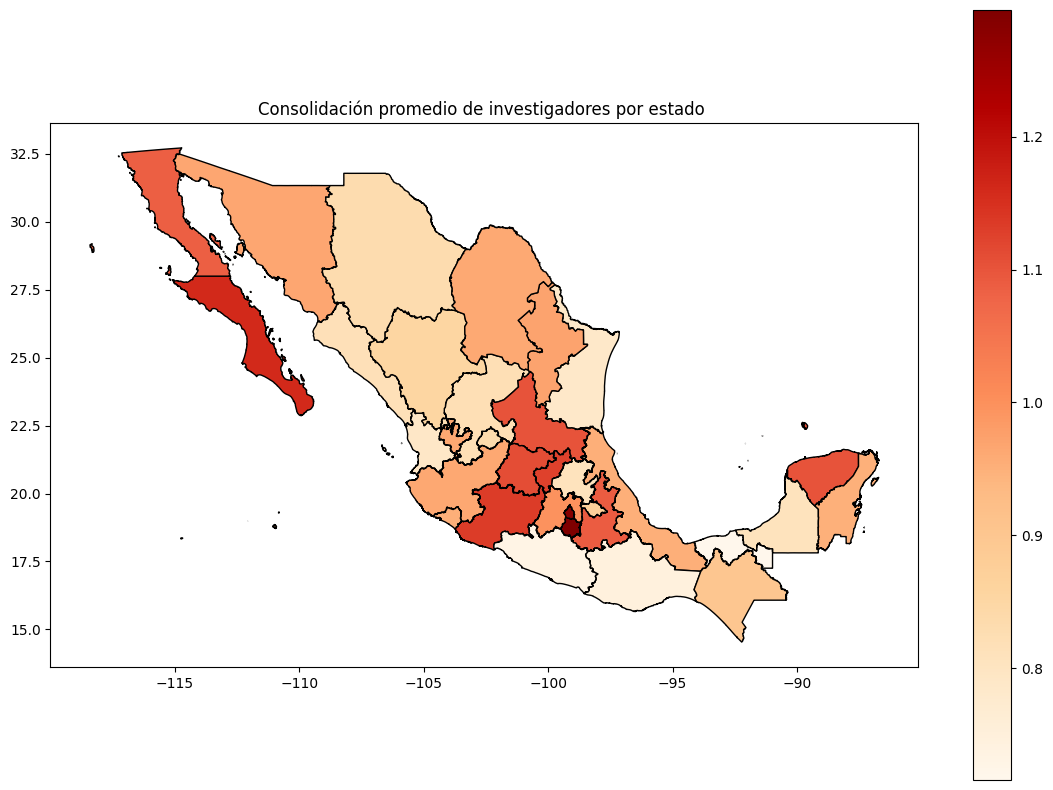

In [ ]:
import unidecode
import matplotlib.pyplot as plt

mexico["nom_ent"] = mexico["nom_ent"].astype(str).apply(unidecode.unidecode)

mexico["nom_ent"] = mexico["nom_ent"].str.upper().str.strip()

replacement_map = {
    "VERACRUZ": "VERACRUZ DE IGNACIO DE LA LLAVE",
    "ESTADO DE MEXICO": "MEXICO",
    "CIUDAD DE MEXICO": "DISTRITO FEDERAL",
    "CDMX": "DISTRITO FEDERAL",
    "MICHOACAN": "MICHOACAN DE OCAMPO",
    "SAN LUIS POTOSI": "SAN LUIS POTOSI",
    "NUEVO LEON": "NUEVO LEON",
    "QUERETARO": "QUERETARO"
}
mexico["nom_ent"] = mexico["nom_ent"].replace(replacement_map)

nivel_estado = df_final_unificado.groupby("ENTIDAD")["Nivel_num"].mean().reset_index()
nivel_estado.columns = ["ENTIDAD", "Consolidacion_Promedio"]

df_geo = mexico.merge(nivel_estado, left_on="nom_ent", right_on="ENTIDAD", how="left")

df_geo.plot(
    figsize=(14,10),
    column="Consolidacion_Promedio",
    cmap="OrRd",
    legend=True,
    edgecolor="black"
)
plt.title("Consolidación promedio de investigadores por estado ")
plt.show()

###Resultado.
El mapa muestra una distribución desigual del nivel dentro del país. Podemos observar que Ciudad de México, Puebla y Querétaro destacan con los valores más altos de consolidación, de igual manera Sonora y Baja California tambien presenta niveles elevados.

Por otro lado, una parte importante del sur y sureste del país muestran valores más bajos de consolidación, lo que indica cominidades más jovenes o menores proporciones de investigadores en niveles altos.

La visualización revela que la consolidacion académica en México está concentrada mayormente en ciertas zonas del país, mientras que otra cantidad importante de estados aún presentan retos para fortalecer su planta de investigación.

In [ ]:
tendencia_niveles = pd.crosstab(df_final_unificado["AÑO"], df_final_unificado["NIVEL"])
tendencia_niveles = tendencia_niveles.drop(
    columns=["NAN", "<NA>"],
)
fig1 = go.Figure()

colores = {
    'C': '#00BFA6',
    '1': '#2979FF',
    '2': '#8E24AA',
    '3': '#FF7043',
}

for nivel in tendencia_niveles.columns:
    fig1.add_trace(go.Scatter(
        x=tendencia_niveles.index,
        y=tendencia_niveles[nivel],
        mode='lines+markers',
        name=f'Nivel {nivel}',
        line=dict(width=3, color=colores.get(nivel, '#999999')),
        marker=dict(size=8)
    ))

fig1.update_layout(
    title='<b>Evolución de Investigadores por Nivel SNI</b>',
    xaxis_title='Año',
    yaxis_title='Número de Investigadores',
    hovermode='x unified',
    height=500,
    legend=dict(title='Nivel', orientation='v', x=1.02, y=1),
    font=dict(size=12)
)

fig1.show()

###Resultado:
La gráfica nos muestra cómo ha cambiado el número de investigadores a lo largo del tiempo. Se observa un crecimiento en todos los niveles durante las últimas dos décadas.

La visualización nos permite ver que en el 2022 hay un salto abrupto, se aprecia un crecimiento considerable en el número de integrantes.




# Análisis estatal

In [ ]:
df_final_unificado["ENTIDAD"] = df_final_unificado["ENTIDAD"].str.strip().str.upper()
estandarizar_estados = {
    "SIN INSTITUCIÓN DE ADSCRIPCIÓN": "SIN INFORMACION",
    "SIN INSTITUCIÓN": "SIN INFORMACION",
    "SIN INSTITUCIÓN REGISTRADA EN EL SNII": "SIN INFORMACION",
    "SIN ACREDITACIONES DISPONIBLES EN EL SISTEMA INFORMATICO (MIIC)": "SIN INFORMACION",
    "EXCEPTUADO CONFORME AL ARTÍCULO 28 FRACCIÓN I DEL REGLAMENTO SNII": "SIN INFORMACION",
    "SIN INFORMACIÓN": "SIN INFORMACION",
    "NAN": "SIN INFORMACION"
}

df_final_unificado = estandarizar_datos(columna="ENTIDAD", mapa=estandarizar_estados)


distribucion_investigadores = df_final_unificado['ENTIDAD'].value_counts().reset_index()
distribucion_investigadores.columns = ['ENTIDAD', 'CONTEO_TOTAL']

In [ ]:
tendencia_investigadores = pd.crosstab(df_final_unificado['AÑO'], df_final_unificado['ENTIDAD'])
tendencia_investigadores.head()

ENTIDAD,AGUASCALIENTES,BAJA CALIFORNIA,BAJA CALIFORNIA SUR,CAMPECHE,CHIAPAS,CHIHUAHUA,COAHUILA,COAHUILA DE ZARAGOZA,COLIMA,DISTRITO FEDERAL,...,SAN LUIS POTOSI,SIN INFORMACION,SINALOA,SONORA,TABASCO,TAMAULIPAS,TLAXCALA,VERACRUZ DE IGNACIO DE LA LLAVE,YUCATAN,ZACATECAS
AÑO,,,,,,,,,,,,,,,,,,,,,
2000,34,230,103,13,52,47,0,95,46,3714,...,90,160,49,122,1,36,16,138,142,46
2001,34,264,119,17,66,51,0,103,46,3894,...,106,88,63,137,12,50,15,160,161,48
2002,41,306,130,23,74,62,0,124,53,4356,...,135,89,76,160,26,61,20,184,181,48
2003,41,306,130,23,74,62,0,124,53,4356,...,135,89,76,160,26,61,20,184,181,48
2004,46,335,137,23,84,83,0,130,55,4752,...,162,90,84,174,40,68,26,211,196,57


### Crecimiento y disminución de investigadores por Año

In [ ]:
df_final_unificado['ENTIDAD'] = df_final_unificado['ENTIDAD'].replace({
    'VERACRUZ DE IGNACIO DE LA LLAVE': 'VERACRUZ'
})

crecimiento_anual = df_final_unificado.groupby('AÑO').size().reset_index(name='VOLUMEN_TOTAL')
crecimiento_anual['CRECIMIENTO_ANUAL'] = crecimiento_anual['VOLUMEN_TOTAL'].diff() #Calcula la diferencia entre un valor y el anterior
def clasificar_diferencia(diferencia):
    if diferencia > 0:
        return 'Crecimiento'
    elif diferencia < 0:
        return 'Disminución'
    else:
        return 'Estancamiento'

crecimiento_anual['TENDENCIA'] = crecimiento_anual['CRECIMIENTO_ANUAL'].apply(clasificar_diferencia)
crecimiento_anual.head()

,AÑO,VOLUMEN_TOTAL,CRECIMIENTO_ANUAL,TENDENCIA
0,2000,7466,NaN,Estancamiento
1,2001,8018,552.0,Crecimiento
2,2002,9199,1181.0,Crecimiento
3,2003,9199,0.0,Estancamiento
4,2004,10189,990.0,Crecimiento


### Crecimiento y disminución de investigadores por Estado en 2024 respecto 2023

In [ ]:
df_filtrar_años = df_final_unificado[(df_final_unificado['AÑO'].isin([2023, 2024])) & (~df_final_unificado['ENTIDAD'].isin(['SIN INFORMACION', 'EXTERIOR']))]
crecimiento_estado = (df_filtrar_años.groupby(['ENTIDAD', 'AÑO']).size().reset_index(name='VOLUMEN_TOTAL'))

tabla_comparacion = (crecimiento_estado.pivot(index='ENTIDAD', columns='AÑO', values='VOLUMEN_TOTAL').fillna(0))

if 2024 in tabla_comparacion.columns and 2023 in tabla_comparacion.columns:
    tabla_comparacion['DIFERENCIA'] = tabla_comparacion[2024] - tabla_comparacion[2023]

tabla_comparacion['TENDENCIA'] = tabla_comparacion['DIFERENCIA'].apply(clasificar_diferencia)
tabla_comparacion = tabla_comparacion.reset_index().sort_values(by='DIFERENCIA', ascending=False)
tabla_comparacion.head()

AÑO,ENTIDAD,2023,2024,DIFERENCIA,TENDENCIA
30,VERACRUZ,5303.0,6018.0,715.0,Crecimiento
6,COAHUILA,0.0,705.0,705.0,Crecimiento
9,DISTRITO FEDERAL,54631.0,55268.0,637.0,Crecimiento
14,JALISCO,10260.0,10871.0,611.0,Crecimiento
15,MEXICO,9014.0,9563.0,549.0,Crecimiento


In [ ]:
df_investigadores_2024 = df_final_unificado[(df_final_unificado['AÑO'] == 2024) & (~df_final_unificado['ENTIDAD'].isin(['SIN INFORMACION', 'EXTERIOR']))]

#Investigadores por estado en 2024
top_2024 = (df_investigadores_2024.groupby('ENTIDAD').size().reset_index(name='TOTAL_INVESTIGADORES').sort_values(by='TOTAL_INVESTIGADORES', ascending=False))
top_2024.head()

,ENTIDAD,TOTAL_INVESTIGADORES
9,DISTRITO FEDERAL,55268
14,JALISCO,10871
15,MEXICO,9563
19,NUEVO LEON,7747
21,PUEBLA,6371


In [ ]:
#Visualizaciones Crecimiento SNI
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        'Investigadores Totales por Año',
        'Estados con Mayor Crecimiento en Investigadores'
    ),
    horizontal_spacing=0.09
)

#Cantidad total de invetigadores por año
fig.add_trace(
    go.Scatter(
        x=crecimiento_anual['AÑO'],
        y=crecimiento_anual['VOLUMEN_TOTAL'],
        mode='lines+markers',
        line=dict(color='#42A5F5', width=3),
        marker=dict(size=10),
        name='Total',
        hovertemplate='%{x}: %{y:,}<extra></extra>'
    ),
    row=1, col=1
)

#Estados con mayor crecimiento en investigadores
top_10 = tabla_comparacion.head(10).sort_values('DIFERENCIA')
colores = ['#66BB6A' if x > 0 else '#EF5350' for x in top_10['DIFERENCIA']]

fig.add_trace(
    go.Bar(
        x=top_10['DIFERENCIA'],
        y=top_10['ENTIDAD'],
        orientation='h',
        marker_color=colores,
        text=top_10['DIFERENCIA'].astype(int),
        textposition='outside',
        hovertemplate='%{y}: %{x:+,}<extra></extra>'
    ),
    row=1, col=2
)

fig.update_xaxes(title_text="Año", row=1, col=1)
fig.update_yaxes(title_text="Investigadores", row=1, col=1)
fig.update_xaxes(title_text="Cambio 2024 vs 2023", row=1, col=2)

fig.update_layout(
    height=500,
    showlegend=False,
    font=dict(size=11),
    plot_bgcolor='white'
)

fig.show()

### Resultado

En general, el número de investigadores en México ha crecido de manera constante. En 2024, todos los estados mantuvieron una tendencia de crecimiento, destacando la Ciudad de México, seguida de Jalisco, mientras que estados como Veracruz y Coahuila sobresalen por su mayor tasa de crecimiento entre 2023 y 2024.

In [ ]:
df_final_unificado["DISCIPLINA"] = df_final_unificado["DISCIPLINA"].astype(str).str.upper().str.strip()
filtro_informatica = filtro_informatica = df_final_unificado[
    df_final_unificado["DISCIPLINA"].str.contains(
        r"\b(INFORMATICA|COMPUTAC|SISTEMAS_COMPUTACIONALES|PROGRAM|SOFTWARE|EASI|"
        r"INTELIGENCIA ARTIFICIAL|CIENCIAS DE LA COMPUTACION|"
        r"INGENIERIA EN SISTEMAS|BASES DE DATOS|TECNOLOGIAS DE LA INFORMACION|"
        r"SEGURIDAD INFORMATICA|REDES|"
        r"CIENCIA DE DATOS|DATA SCIENCE|INFORMATIVO|"
        r"CIBERSEGURIDAD|TIC|TECNOLOGIA EDUCATIVA)\b",
        case=False,
        na=False
    )
]

filtro_informatica.head()

/tmp/ipython-input-3438969712.py:3: UserWarning:

This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.



,AÑO,AREA_CONOCIMIENTO,CATEGORIA,DEPENDENCIA,DISCIPLINA,EMERITO,ENTIDAD,ESPECIALIDAD,FECHA_FIN_VIGENCIA,FECHA_INICIO_VIGENCIA,GRADO_ACADEMICO,INSTITUCION,NIVEL,SUBDISCIPLINA,PAIS,Nivel_num
372694,2022,INGENIERÍAS,<NA>,DEPARTAMENTO DE INGENIERIA ELECTRICA,TECNOLOGIA DE LA INFORMATICA,NaN,DISTRITO FEDERAL,AUTOMATIZACION Y CONTROL,2029-12-31 00:00:00,2013-01-02 00:00:00,None,CENTRO DE INVESTIGACION Y DE ESTUDIOS AVANZADO...,INVESTIGADOR(A) NACIONAL NIVEL III,DISPOSITIVOS DE CONTROL,MÉXICO,NaN
372736,2022,INGENIERÍAS,<NA>,INSTITUTO TECNOLÓGICO DE CIUDAD MADERO,CIENCIAS DE LA COMPUTACION,NaN,TAMAULIPAS,INTELIGENCIA ARTIFICIAL,2034-12-31 00:00:00,2016-01-02 00:00:00,None,TECNOLÓGICO NACIONAL DE MÉXICO,INVESTIGADOR(A) NACIONAL NIVEL II,OTROS,MÉXICO,NaN
372773,2022,FÍSICO-MATEMÁTICAS Y TIERRA,<NA>,UNIDAD TAMAULIPAS,INFORMATICA MATEMATICA,NaN,TAMAULIPAS,"OPTIMIZACIÓN COMBINATORIA, COVERING ARRAYS",2022-12-31 00:00:00,2018-01-01 00:00:00,None,CENTRO DE INVESTIGACION Y DE ESTUDIOS AVANZADO...,INVESTIGADOR(A) NACIONAL NIVEL III,INTELIGENCIA ARTIFICIAL,MÉXICO,NaN
372828,2022,INGENIERÍAS,<NA>,COORDINACION DE INVESTIGACION CIENTIFICA,INFORMATICA MATEMATICA,NaN,DISTRITO FEDERAL,REDES NEURONALES,2029-12-31 00:00:00,2012-01-02 00:00:00,None,UNIVERSIDAD NACIONAL AUTONOMA DE MEXICO,INVESTIGADOR(A) NACIONAL NIVEL III,INTELIGENCIA ARTIFICIAL,MÉXICO,NaN
373021,2022,INGENIERÍAS,<NA>,COORDINACION DE INVESTIGACION CIENTIFICA,TECNOLOGIA DE LA INFORMATICA,NaN,DISTRITO FEDERAL,SISTEMAS DE SOPORTE INFORMÁTICO EN ORGANIZACIONES,2024-12-30 00:00:00,2010-01-02 00:00:00,None,UNIVERSIDAD NACIONAL AUTONOMA DE MEXICO,INVESTIGADOR(A) NACIONAL NIVEL I,NaN,MÉXICO,NaN


### Aumento/disminución de tipo de nivel a lo largo de lo años


In [ ]:
tendencia_niveles = pd.crosstab(df_final_unificado["AÑO"], df_final_unificado["NIVEL"])
tendencia_niveles = tendencia_niveles.drop(
    columns=["NAN", "<NA>"],
)
tendencia_niveles.head()

NIVEL,1,2,3,1,2,3,C,CANDIDATO(A) A INVESTIGADOR NACIONAL,CANDIDATO(A) A INVESTIGADOR(A) NACIONAL,INVESTIGADOR(A) NACIONAL NIVEL I,INVESTIGADOR(A) NACIONAL NIVEL II,INVESTIGADOR(A) NACIONAL NIVEL III
AÑO,,,,,,,,,,,,
2000,0,0,0,4346,1278,622,1220,0,0,0,0,0
2001,0,0,0,4682,1556,652,1128,0,0,0,0,0
2002,0,0,0,5385,1729,762,1323,0,0,0,0,0
2003,0,0,0,5385,1729,762,1323,0,0,0,0,0
2004,0,0,0,5784,1898,876,1631,0,0,0,0,0


In [ ]:
tendencia_niveles_proporcional = (
    tendencia_niveles.div(tendencia_niveles.sum(axis=1), axis=0) * 100
)

tendencia_niveles_proporcional.head()

NIVEL,1,2,3,1,2,3,C,CANDIDATO(A) A INVESTIGADOR NACIONAL,CANDIDATO(A) A INVESTIGADOR(A) NACIONAL,INVESTIGADOR(A) NACIONAL NIVEL I,INVESTIGADOR(A) NACIONAL NIVEL II,INVESTIGADOR(A) NACIONAL NIVEL III
AÑO,,,,,,,,,,,,
2000,0.0,0.0,0.0,58.210555,17.117600,8.331101,16.340745,0.0,0.0,0.0,0.0,0.0
2001,0.0,0.0,0.0,58.393614,19.406336,8.131704,14.068346,0.0,0.0,0.0,0.0,0.0
2002,0.0,0.0,0.0,58.538972,18.795521,8.283509,14.381998,0.0,0.0,0.0,0.0,0.0
2003,0.0,0.0,0.0,58.538972,18.795521,8.283509,14.381998,0.0,0.0,0.0,0.0,0.0
2004,0.0,0.0,0.0,56.767102,18.627932,8.597507,16.007459,0.0,0.0,0.0,0.0,0.0


### Resultado
El porcentaje de Candidatos (C) y de Nivel 1 es cada vez mayor, lo que solo puede significar que está entrando muchos investigadores nuevos al sistema.
Por otro lado, los niveles 2 y 3 están perdiendo peso en el total. Pero, no que haya menos investigadores en esos niveles, sino que el porcentaje total es menor.

In [ ]:
df_chihuahua = df_final_unificado[df_final_unificado["ENTIDAD"] == "CHIHUAHUA"]

conteo_areas = df_chihuahua["AREA_CONOCIMIENTO"].value_counts()
print("Investigadores por área de conocimiento en Chihuahua")
conteo_areas


Investigadores por área de conocimiento en Chihuahua


,count
AREA_CONOCIMIENTO,
INGENIERÍAS,3033
CIENCIAS SOCIALES,2828
"HUMANIDADES, CONDUCTA Y EDUCACIÓN",2562
CIENCIAS AGROPECUARIAS Y AMBIENTALES,2459
BIOLOGÍA Y QUÍMICA,1211
FÍSICO-MATEMÁTICAS Y TIERRA,1119
MEDICINA Y CIENCIAS DE LA SALUD,683
INTERDISCIPLINARIA,180


In [ ]:
porcentaje_areas = df_chihuahua["AREA_CONOCIMIENTO"].value_counts(normalize=True) * 100
print("Porcentaje de investigadores por área de conocimiento en Chihuahua")
porcentaje_areas

Porcentaje de investigadores por área de conocimiento en Chihuahua


,proportion
AREA_CONOCIMIENTO,
INGENIERÍAS,21.548845
CIENCIAS SOCIALES,20.092362
"HUMANIDADES, CONDUCTA Y EDUCACIÓN",18.202487
CIENCIAS AGROPECUARIAS Y AMBIENTALES,17.470693
BIOLOGÍA Y QUÍMICA,8.603908
FÍSICO-MATEMÁTICAS Y TIERRA,7.950266
MEDICINA Y CIENCIAS DE LA SALUD,4.852575
INTERDISCIPLINARIA,1.278863


In [ ]:
tabla_areas_anual = pd.crosstab(df_chihuahua["AÑO"], df_chihuahua["AREA_CONOCIMIENTO"])
print("Evolución de las áreas de conocimiento en Chihuahua:")
tabla_areas_anual.head()

Evolución de las áreas de conocimiento en Chihuahua:


AREA_CONOCIMIENTO,BIOLOGÍA Y QUÍMICA,CIENCIAS AGROPECUARIAS Y AMBIENTALES,CIENCIAS SOCIALES,FÍSICO-MATEMÁTICAS Y TIERRA,"HUMANIDADES, CONDUCTA Y EDUCACIÓN",INGENIERÍAS,INTERDISCIPLINARIA,MEDICINA Y CIENCIAS DE LA SALUD
AÑO,,,,,,,,
2000,5,8,6,5,6,16,0,1
2001,7,14,6,4,6,13,0,1
2002,8,11,8,6,8,20,0,1
2003,8,11,8,6,8,20,0,1
2004,10,16,7,10,9,29,0,2


In [ ]:
#Distribución por Área
fig1 = px.bar(
    x=conteo_areas.values,
    y=conteo_areas.index,
    orientation='h',
    title='Investigadores por Área de Conocimiento en Chihuahua',
    labels={'x': 'Número de Investigadores', 'y': 'Área de Conocimiento'},
    color=conteo_areas.values,
    color_continuous_scale='Blues',
    text=conteo_areas.values
)

fig1.update_traces(textposition='outside')
fig1.update_layout(
    height=500,
    showlegend=False,
    font=dict(size=12)
)
fig1.show()

#Evolución Temporal Áreas de Conocimiento
fig3 = go.Figure()

colores_linea = px.colors.qualitative.Bold

for i, area in enumerate(tabla_areas_anual.columns):
    fig3.add_trace(go.Scatter(
        x=tabla_areas_anual.index,
        y=tabla_areas_anual[area],
        mode='lines+markers',
        name=area,
        line=dict(width=2.5, color=colores_linea[i % len(colores_linea)]),
        marker=dict(size=7)
    ))

fig3.update_layout(
    title='Evolución de Áreas de Conocimiento en Chihuahua',
    xaxis_title='Año',
    yaxis_title='Número de Investigadores',
    hovermode='x unified',
    height=500,
    legend=dict(orientation='v', x=1.02, y=1),
    font=dict(size=12)
)
fig3.show()


#Áreas por Año
fig4 = px.imshow(
    tabla_areas_anual.T,
    labels=dict(x="Año", y="Área de Conocimiento", color="Investigadores"),
    x=tabla_areas_anual.index,
    y=tabla_areas_anual.columns,
    color_continuous_scale='YlOrRd',
    aspect='auto',
    title='Áreas de Conocimiento por Año'
)

fig4.update_layout(
    height=500,
    font=dict(size=11)
)
fig4.show()

### Resultado
El estado de Chihuahua muestra que las áreas con mayor concentración son las ingenierías, ciencias sociales y humanidades, conducta y educación. Las áreas con menor representación son medicina y ciencias de salud e interdisciplinaria.

La evolución anual revela un crecimiento constante en todas las áreas a lo largo de los años, con un crecimiento pronunciado a partir del 2022, especialmente en ciencias sociales y humanidades. También se muestra un decrecimiento en el área de ingenierías entre los años 2023 y 2024.

In [ ]:
df_chihuahua = df_final_unificado[df_final_unificado['ENTIDAD'] == 'CHIHUAHUA']

#Distribución total de investigadores en Chihuahua
distribucion_chihuahua = df_chihuahua['ENTIDAD'].value_counts().reset_index()
distribucion_chihuahua.columns = ['ENTIDAD', 'CONTEO_TOTAL']

#Tendencia anual de investigadores en Chihuahua
tendencia_chihuahua = pd.crosstab(df_chihuahua['AÑO'], df_chihuahua['ENTIDAD'])

print("Distribución total de investigadores en Chihuahua:")
distribucion_chihuahua.iloc[0, 1]




Distribución total de investigadores en Chihuahua:


np.int64(14075)

In [ ]:
print("Tendencia de investigadores en Chihuahua por año:")
tendencia_chihuahua.head()

Tendencia de investigadores en Chihuahua por año:


ENTIDAD,CHIHUAHUA
AÑO,
2000,47
2001,51
2002,62
2003,62
2004,83


In [ ]:
tendencia_chihuahua = tendencia_chihuahua.rename(columns={'CHIHUAHUA': 'INVESTIGADORES'})
tendencia_chihuahua = tendencia_chihuahua.reset_index()

fig = px.area(
    tendencia_chihuahua,
    x="AÑO",
    y="INVESTIGADORES",
    title="Evolución de Investigadores en Chihuahua",
    markers=True,
    color_discrete_sequence=["#66BB6A"]
)

fig.update_traces(opacity=0.7, line=dict(width=3))
fig.update_layout(
    title_x=0.5,
    font=dict(size=13),
    plot_bgcolor="white",
    xaxis_title="Año",
    yaxis_title="Cantidad de Investigadores"
)

fig.show()


### Resultado

El análisis muestra que el estado de Chihuahua cuenta con 14,075 investigadores. La tendecia anual indica un crecimiento constante de investigadores. A partir del 2022, se registra un incremento muy notorio en el número de investigadores.

### Emeritos en Chihuahua

In [ ]:
emeritos = df_final_unificado[df_final_unificado['CATEGORIA'] == 'EMERITO']
emeritos_por_estado = emeritos['ENTIDAD'].value_counts().reset_index()
emeritos_por_estado.columns = ['ENTIDAD', 'TOTAL_EMERITOS']
mayor_estado = emeritos_por_estado.iloc[0]
print(f"Estado con más investigadores eméritos: {mayor_estado['ENTIDAD']} ({mayor_estado['TOTAL_EMERITOS']} eméritos)")

Estado con más investigadores eméritos: DISTRITO FEDERAL (5765 eméritos)


In [ ]:
emeritos_chihuahua = emeritos_por_estado[emeritos_por_estado['ENTIDAD'].isin(['CHIHUAHUA'])].iloc[0]
print(f"Estado de Chihuahua: {emeritos_chihuahua['TOTAL_EMERITOS']} eméritos")

Estado de Chihuahua: 33 eméritos


In [ ]:
df_emeritos = pd.DataFrame({
    'Estado': [mayor_estado['ENTIDAD'], 'CHIHUAHUA'],
    'Eméritos': [mayor_estado['TOTAL_EMERITOS'], emeritos_chihuahua['TOTAL_EMERITOS']]
})

# Investigadores totales
total_investigadores = df_final_unificado[df_final_unificado['ENTIDAD'].isin([mayor_estado['ENTIDAD'], 'CHIHUAHUA'])]
df_totales = total_investigadores['ENTIDAD'].value_counts().reset_index()
df_totales.columns = ['Estado', 'Total_Investigadores']


fig = make_subplots(
    rows=1, cols=2,

    specs=[[{"type": "pie"}, {"type": "bar"}]],
    horizontal_spacing=0.15
)

fig.add_trace(
    go.Pie(
        labels=df_emeritos['Estado'],
        values=df_emeritos['Eméritos'],
        textposition='outside',
        textinfo='label+percent',
        texttemplate='<b>%{label}</b><br>%{percent}<br>( Eméritos: %{value:,})',
        marker_colors=['#1f77b4', '#ff7f0e'],
        hole=0.4,
        hovertemplate='<b>%{label}</b><br>Eméritos: %{value:,}<br>Porcentaje: %{percent}<extra></extra>',
        textfont=dict(size=12),
    ),
    row=1, col=1
)

fig.add_trace(
    go.Bar(
        x=df_totales['Estado'],
        y=df_totales['Total_Investigadores'],
        text=df_totales['Total_Investigadores'].apply(lambda x: f'{x:,}'), #Formatea el numero con coma como separador de miles
        textposition='outside',
        marker_color=['#1f77b4', '#ff7f0e'],
        hovertemplate='<b>%{x}</b><br>Total: %{y:,}<extra></extra>'
    ),
    row=1, col=2
)

fig.update_layout(
    height=500,
    width=1000,
    title_text=f"<b>Comparación: {mayor_estado['ENTIDAD']} vs Chihuahua</b>",
    title_x=0.5,
    title_font_size=18,
    showlegend=False,
    font=dict(size=12),
    plot_bgcolor='white',
    paper_bgcolor='white'
)

fig.update_xaxes(title_text="Estado", row=1, col=2)
fig.update_yaxes(title_text="Investigadores Totales", row=1, col=2)


fig.show()

### Resultado
La gráfica muestra que la Ciudad de México concentra la mayor cantidad de investigadores eméritos, exactamente 5,765. En contraste, el estado de Chihuahua cuenta con 33 investigadores eméritos, representado una proporción significativamente menor tanto de investigadores eméritos como de investigadores totales en comparación con la Ciudad de México.

In [ ]:
conteo_areas_por_institucion = df_local.groupby('INSTITUCION')['AREA_CONOCIMIENTO'].value_counts().reset_index(name='Cantidad')


def filtrar_por_institucion(df, institucion):
    return df[df['INSTITUCION'] == institucion]


conteo_uacj = filtrar_por_institucion(conteo_areas_por_institucion, 'UACJ')
conteo_uach = filtrar_por_institucion(conteo_areas_por_institucion, 'UACH')


conteo_areas_por_institucion.head()


,INSTITUCION,AREA_CONOCIMIENTO,Cantidad
0,UACH,CIENCIAS AGROPECUARIAS Y AMBIENTALES,1454
1,UACH,"HUMANIDADES, CONDUCTA Y EDUCACIÓN",774
2,UACH,CIENCIAS SOCIALES,761
3,UACH,BIOLOGÍA Y QUÍMICA,525
4,UACH,INGENIERÍAS,481


In [ ]:
porcentaje_areas_por_institucion = df_local.groupby('INSTITUCION')['AREA_CONOCIMIENTO'].value_counts(normalize=True) * 100
print("\nPorcentaje de áreas por institución:")
porcentaje_areas_por_institucion.head()


Porcentaje de áreas por institución:


INSTITUCION  AREA_CONOCIMIENTO                   
UACH         CIENCIAS AGROPECUARIAS Y AMBIENTALES    31.161595
             HUMANIDADES, CONDUCTA Y EDUCACIÓN       16.588084
             CIENCIAS SOCIALES                       16.309473
             BIOLOGÍA Y QUÍMICA                      11.251607
             INGENIERÍAS                             10.308616
Name: proportion, dtype: float64

In [ ]:
df_uacj = df_local[df_local['INSTITUCION'] == 'UACJ']
tendencia_uacj_area  = df_uacj.groupby(['AÑO', 'AREA_CONOCIMIENTO']).size().unstack(fill_value=0)
tendencia_uacj_area.head()


AREA_CONOCIMIENTO,BIOLOGÍA Y QUÍMICA,CIENCIAS AGROPECUARIAS Y AMBIENTALES,CIENCIAS SOCIALES,FÍSICO-MATEMÁTICAS Y TIERRA,"HUMANIDADES, CONDUCTA Y EDUCACIÓN",INGENIERÍAS,INTERDISCIPLINARIA,MEDICINA Y CIENCIAS DE LA SALUD
AÑO,,,,,,,,
2000,1,1,4,1,2,1,0,0
2001,3,1,4,0,3,0,0,0
2002,6,1,5,0,3,0,0,0
2003,6,1,5,0,3,0,0,0
2004,6,1,3,0,3,0,0,0


In [ ]:
df_uach = df_local[df_local['INSTITUCION'] == 'UACH']
tendencia_uach_area = df_uacj.groupby(['AÑO', 'AREA_CONOCIMIENTO']).size().unstack(fill_value=0)
tendencia_uach_area.head()


AREA_CONOCIMIENTO,BIOLOGÍA Y QUÍMICA,CIENCIAS AGROPECUARIAS Y AMBIENTALES,CIENCIAS SOCIALES,FÍSICO-MATEMÁTICAS Y TIERRA,"HUMANIDADES, CONDUCTA Y EDUCACIÓN",INGENIERÍAS,INTERDISCIPLINARIA,MEDICINA Y CIENCIAS DE LA SALUD
AÑO,,,,,,,,
2000,1,1,4,1,2,1,0,0
2001,3,1,4,0,3,0,0,0
2002,6,1,5,0,3,0,0,0
2003,6,1,5,0,3,0,0,0
2004,6,1,3,0,3,0,0,0


In [ ]:
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("UACJ", "UACH")
)

# Gráfico UACJ
fig.add_trace(
    go.Bar(
        x=conteo_uacj['AREA_CONOCIMIENTO'],
        y=conteo_uacj['Cantidad'],
        text=conteo_uacj['Cantidad'],
        textposition='auto',
        marker_color='steelblue',
        name='UACJ'
    ),
    row=1, col=1
)

# Gráfico UACH
fig.add_trace(
    go.Bar(
        x=conteo_uach['AREA_CONOCIMIENTO'],
        y=conteo_uach['Cantidad'],
        text=conteo_uach['Cantidad'],
        textposition='auto',
        marker_color='darkorange',
        name='UACH'
    ),
    row=1, col=2
)

fig.update_layout(
    height=500,
    width=1150,
    title_text="Conteo de Áreas de Conocimiento - UACJ vs UACH",
    showlegend=False
)

fig.show()


### Resultado
El análisis muestra que la mayoría de los investigadores de la UACJ estan orientados en las ciencias sociales, humanidades con un total de 1,597 investigadores. Por su parte, los investigadores de la UACH, se enfocan principalmente en ciencias agropecuarias y ambientales, con 1,454 investigadores.

Tanto la UACJ como UACH presentan un aumento constante en invetigadores en todas las áreas a lo largo del tiempo. En particular, durante los años 2023 y 2024, se observa un incremento muy notable en casi todas las áreas de conocimiento.

In [ ]:
df_local['GRADO_ACADEMICO'].unique()

array(['Doctorado', 'Licenciatura', 'Maestría', 'Medicina', None],
      dtype=object)

In [ ]:
contar_grado_academico = df_local.groupby(['INSTITUCION', 'GRADO_ACADEMICO']).size().reset_index(name='Cantidad')
contar_grado_academico

,INSTITUCION,GRADO_ACADEMICO,Cantidad
0,UACH,Doctorado,2801
1,UACH,Licenciatura,50
2,UACH,Maestría,65
3,UACH,Medicina,13
4,UACJ,Doctorado,3887
5,UACJ,Licenciatura,27
6,UACJ,Maestría,111
7,UACJ,Medicina,11


In [ ]:
fig = px.bar(
    contar_grado_academico,
    x='GRADO_ACADEMICO',
    y='Cantidad',
    color='INSTITUCION',
    barmode='group',
    text='Cantidad',
    title='Comparación de investigadores por Grado Académico: UACJ vs UACH'
)

fig.update_traces(textposition='outside')
fig.update_layout(yaxis_title='Número de Investigadores', xaxis_title='Grado Académico')
fig.show()

### Resultado

El análisis muestra que tanto en la UACJ como en la UACH, la mayoría de los investigadores poseen un doctorado, con 3,8887 y 2,801 investigadores respectivamente. Las demás categorías son significativamente menores en número de investigadores.

In [ ]:
emeritos_locales = (df_local['CATEGORIA'] == 'EMERITO').sum()
emeritos_locales

np.int64(0)

##Comparación del perfil de investigador. UACJ VS UACH

In [ ]:
unis = ["UACJ", "UACH"]
df_unis = df_local[df_local["INSTITUCION"].isin(unis)]

mapa_niveles = {"C": 0, "1": 1, "2": 2, "3": 3}
df_unis["Nivel_num"] = df_unis["NIVEL"].map(mapa_niveles)

In [ ]:
nivel_promedio = df_unis.groupby("INSTITUCION")["Nivel_num"].mean()
nivel_promedio


,Nivel_num
INSTITUCION,
UACH,0.752938
UACJ,0.791045


In [ ]:
df_unis["Consolidado"] = df_unis["NIVEL"].isin(["2", "3"])

consolidacion = df_unis.groupby("INSTITUCION")["Consolidado"].mean() * 100
consolidacion

niveles = df_unis.groupby(["INSTITUCION", "NIVEL"]).size().unstack(fill_value=0)
niveles

grados = df_unis.groupby(["INSTITUCION", "GRADO_ACADEMICO"]).size().unstack(fill_value=0)
grados

areas = df_unis.groupby(["INSTITUCION", "AREA_CONOCIMIENTO"]).size().unstack(fill_value=0)
areas

AREA_CONOCIMIENTO,BIOLOGÍA Y QUÍMICA,CIENCIAS AGROPECUARIAS Y AMBIENTALES,CIENCIAS SOCIALES,FÍSICO-MATEMÁTICAS Y TIERRA,"HUMANIDADES, CONDUCTA Y EDUCACIÓN",INGENIERÍAS,INTERDISCIPLINARIA,MEDICINA Y CIENCIAS DE LA SALUD
INSTITUCION,,,,,,,,
UACH,525,1454,761,203,774,481,81,387
UACJ,374,545,1597,466,1419,1074,83,258


In [ ]:
perfil = pd.DataFrame({
    "Total investigadores": df_unis.groupby("INSTITUCION").size(),
    "Nivel_promedio": nivel_promedio,
    "% Consolidados (Nivel 2 y 3)": consolidacion,
})

perfil

,Total investigadores,Nivel_promedio,% Consolidados (Nivel 2 y 3)
INSTITUCION,,,
UACH,4666,0.752938,6.858123
UACJ,5816,0.791045,6.482118


In [ ]:
from plotly.subplots import make_subplots

def crear_radar_comparativo(perfil):
    """
    Radar chart comparando métricas generales entre UACJ y UACH
    """
    categorias = ['Total investigadores', 'Nivel promedio', '% Consolidados']

    # Normalizar valores a escala 0-100 para mejor visualización
    uacj_vals = perfil.loc['UACJ'].values
    uach_vals = perfil.loc['UACH'].values

    # Normalización por máximo de cada categoría
    max_vals = [max(uacj_vals[i], uach_vals[i]) for i in range(len(uacj_vals))]
    uacj_norm = [(uacj_vals[i] / max_vals[i] * 100) for i in range(len(uacj_vals))]
    uach_norm = [(uach_vals[i] / max_vals[i] * 100) for i in range(len(uach_vals))]

    fig = go.Figure()

    fig.add_trace(go.Scatterpolar(
        r=uacj_norm,
        theta=categorias,
        fill='toself',
        name='UACJ',
        line=dict(color='#3b82f6', width=2),
        fillcolor='rgba(59, 130, 246, 0.3)'
    ))

    fig.add_trace(go.Scatterpolar(
        r=uach_norm,
        theta=categorias,
        fill='toself',
        name='UACH',
        line=dict(color='#10b981', width=2),
        fillcolor='rgba(16, 185, 129, 0.3)'
    ))

    fig.update_layout(
        polar=dict(
            radialaxis=dict(visible=True, range=[0, 100])
        ),
        title='Comparación General: UACJ vs UACH (Normalizado)',
        showlegend=True,
        height=500
    )

    return fig

fig_radar = crear_radar_comparativo(perfil)
fig_radar.show()


###Resultado:
Esta gráfica de radar nos permite observar que la UACJ presenta un valor ligeramente mayor en cuanto a número de investigadores. Sin embargo, ambas instituciones muestran valores equivalentes en el nivel promedio, lo que nos da a entender que los investigadores de ambas universidades mantienen un desempeño similar. Por último, el indicador de investigadores consolidados muestra que a pesar de las diferencias en el tamaño de población, el grado de consolidación es semejante.

In [ ]:
def crear_heatmap_area_nivel_vertical(df_unis, top_areas=8):
    """
    Heatmap mostrando la distribución de investigadores por área y nivel
    para cada universidad (vertical)
    """
    # Identificar top áreas
    top_areas_list = df_unis['AREA_CONOCIMIENTO'].value_counts().head(top_areas).index
    df_filtered = df_unis[df_unis['AREA_CONOCIMIENTO'].isin(top_areas_list)]

    universidades = df_filtered['INSTITUCION'].unique()

    # Crear subplots verticales
    fig = make_subplots(
        rows=len(universidades), cols=1,
        subplot_titles=[f'<b>{uni}</b>' for uni in universidades],
        vertical_spacing=0.12
    )

    for idx, uni in enumerate(universidades, 1):
        df_uni = df_filtered[df_filtered['INSTITUCION'] == uni]

        # Matriz área × nivel
        matriz = pd.crosstab(
            df_uni['AREA_CONOCIMIENTO'],
            df_uni['NIVEL']
        )

        # Reordenar niveles
        niveles_orden = ['C', '1', '2', '3', 'E']
        matriz = matriz.reindex(columns=[n for n in niveles_orden if n in matriz.columns],
                               fill_value=0)

        fig.add_trace(
            go.Heatmap(
                z=matriz.values,
                x=matriz.columns,
                y=matriz.index,
                colorscale='Blues' if uni == 'UACJ' else 'Greens',
                text=matriz.values,
                texttemplate='%{text}',
                textfont={"size": 10},
                showscale=False
            ),
            row=idx, col=1
        )

        fig.update_xaxes(title_text="Nivel SNI", row=idx, col=1)
        fig.update_yaxes(title_text="Área", row=idx, col=1)

    fig.update_layout(
        title='Distribución: Área × Nivel × Universidad (Vertical)',
        height=1200,
        showlegend=False
    )

    return fig

fig7 = crear_heatmap_area_nivel_vertical(df_unis, top_areas=8)
fig7.show()


###Resultado:
Estos mapas de calor nos indican la cantidad de investigadores en cada disciplina y nivel. Podemos observar la UACJ tiene las poblaciones más altas en las áreas de Ciencias Sociales y Humanidades, ambos en el nivel 1.
Por el lado de la UACH, con una diferencia muy marcada, la población de investigadores de Ciencias Agropecuarias y Ambientales del nivel 1 son la más abundante, el resto de áreas tiene una cantidad de investigadores más semejante.

In [ ]:
def crear_barras_niveles(niveles):
    """
    Gráfico de barras agrupadas mostrando distribución por nivel SNI
    """
    df_niveles = niveles.reset_index()

    niveles_validos = ["C", "1", "2", "3"]
    niveles_existentes = [n for n in niveles_validos if n in df_niveles.columns]

    fig = go.Figure()

    for uni in df_niveles['INSTITUCION'].unique():
        data = df_niveles[df_niveles['INSTITUCION'] == uni]

        fig.add_trace(go.Bar(
            x=niveles_existentes,
            y=data[niveles_existentes].iloc[0].values,
            name=uni,
            text=data[niveles_existentes].iloc[0].values,
            textposition='outside',
            marker=dict(
                color='#3b82f6' if uni == 'UACJ' else '#10b981',
                line=dict(color='white', width=2)
            )
        ))

    fig.update_layout(
        title='Distribución por Nivel SNI',
        xaxis_title='Nivel',
        yaxis_title='Número de Investigadores',
        barmode='group',
        height=500
    )

    return fig

fig = crear_barras_niveles(niveles)
fig.show()

###Resultado:
Esta gráfica compara la cantidad de investigadores por nivel entre UACJ y UACH. En la que se puede visualizar que los investigadores de nivel 1 son con diferencia los más abundantes, siendo la UACJ la que más cuenta con los de este tipo. Además que en los niveles Candidato y dos también mantiene superioridad.
Sin embargo, la UACH destaca en que posee una mayor cantidad de investigadores de nivel 3, cabe recalcarr que la diferencia no es muy amplia.

In [ ]:


def crear_barras_areas_top(areas, top_n=10):
    """
    Gráfico de barras apiladas con las top N áreas
    """
    # Calcular totales y seleccionar top N
    df_areas = areas.T
    df_areas['Total'] = df_areas.sum(axis=1)
    df_areas = df_areas.sort_values('Total', ascending=False).head(top_n)

    fig = go.Figure()

    for uni in areas.index:
        fig.add_trace(go.Bar(
            x=df_areas.index,
            y=df_areas[uni],
            name=uni,
            text=df_areas[uni],
            textposition='inside',
            marker=dict(color='#3b82f6' if uni == 'UACJ' else '#10b981')
        ))

    fig.update_layout(
        title=f'Top {top_n} Áreas de Conocimiento por Universidad',
        xaxis_title='Área',
        yaxis_title='Número de Investigadores',
        barmode='stack',
        height=500,
        xaxis_tickangle=-45
    )

    return fig

fig5 = crear_barras_areas_top(areas, top_n=10)
fig5.show()

###Resultados:
Esta gráfica nos permite observar la diferencia en la cantidad de investigadores en cada Área de conocimiento por universidad. Podemos ver que la UACJ cuenta con más investigadores en más áreas que su competencia. Al igual que las barras nos comunican la reciente incorporación del área interdisciplinaria al ser por diferencia descomunal la de menor cantidad.

# Conclusión
El análisis muestra un crecimiento notable de la comunidad científica en México, especialmente a partir de 2022, cuando se observa un incremento abrupto en el número de investigadores. Las ciencias sociales y el área de biología y química concentran la mayor cantidad de integrantes, aunque esto no se traduce en un mayor nivel de consolidación. De hecho, las áreas con mayor proporción de investigadores de Nivel 3 son Físico-Matemáticas y Ciencias de la Tierra, mientras que el área interdisciplinaria mantiene una proporción baja debido a su reciente incorporación al sistema.

A nivel geográfico, la consolidación académica se distribuye de manera desigual. La Ciudad de México, Puebla, Querétaro, Sonora y Baja California presentan los niveles más altos, mientras que los estados del sur y sureste muestran valores menores, lo que refleja comunidades científicas más jóvenes o con menor presencia en niveles avanzados. A pesar de estas diferencias, todos los estados mantienen una tendencia de crecimiento, con Veracruz y Coahuila destacando por su incremento reciente.

En el caso de Chihuahua, las áreas más representativas son las ingenierías, ciencias sociales y humanidades, observándose un crecimiento marcado desde 2022. Además, los datos revelan la gran concentración de investigadores eméritos en la Ciudad de México frente a cifras significativamente menores en otros estados, como Chihuahua.

La comparación entre la UACJ y la UACH confirma diferencias en su composición disciplinaria: la UACJ concentra más investigadores en ciencias sociales y humanidades, mientras que la UACH destaca en ciencias agropecuarias. Sin embargo, ambas instituciones han mostrado crecimiento constante, predominio del grado de doctorado y niveles de consolidación promedio similares.

En conjunto, las visualizaciones reflejan un sistema científico nacional en expansión, con áreas consolidadas, nuevos campos en desarrollo y contrastes regionales que representan tanto avances como retos para fortalecer la investigación en el país.